In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np
import pandas as pd
import geopandas as gpd
# import tesspy
import shapely
import matplotlib.dates as mdates

import random
import dill
from pathlib import Path
import os
from dotenv import load_dotenv

from fame import *
from fame_msa_utils import ShipTracker, ship_propagator, custom_ship_phenomenon_processor, propagate_distribution_from_observations

import h3
import cdsapi
import xarray as xr



In [2]:
R_earth_km = 6371

g0 =  9.80665


## Load satellites

In [ ]:
# Space-Track Credentials
load_dotenv()
space_track_user = os.environ.get('SPACE_TRACK_USER') 
space_track_password = os.environ.get('SPACE_TRACK_PW')


User: davidf@jpl.nasa.gov, password: Conillera-2801Ff


In [4]:
tle_file_name_json = "tles/all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "tles/all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
        print(all_tles_for_today)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [5]:
# tle_file_name_txt = "tles/all_tles_20260130.txt"
#tle_file_name_txt = "tles/all_tles_20260427.txt"

min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
# max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+ dt.timedelta(seconds=3600*24*2)

lookahead_horizon_h = 36


#min_time = dt.datetime.strptime("2026-04-27 00:00:00.00000", "%Y-%m-%d %H:%M:%S.%f").replace(tzinfo=None)
max_time=min_time + dt.timedelta(seconds=3600*lookahead_horizon_h)


In [6]:
flock_names = []

iceye_names = []

with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("FLOCK"):
            # .strip() removes the trailing newline character (\n)
            flock_names.append(line.strip()) 
            
with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("ICEYE"):
            # .strip() removes the trailing newline character (\n)
            iceye_names.append(line.strip()) 


In [7]:
print(f"There are {len(flock_names)} Flock sats and {len(iceye_names)} ICEYE sats")

There are 124 Flock sats and 52 ICEYE sats


In [8]:
# planet_satellites = []
# 14-19 decayed

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Ubotica ACCENTURE-1 SUAC": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}
for dove_name in flock_names:
    swaths_at_nadir_km[dove_name] =  16.4 #https://www.newspace.im/constellations/planet-labs

for iceye_name in iceye_names:
    swaths_at_nadir_km[iceye_name] =  100 # Scan imaging, https://sar.iceye.com/5.2.3/productguide/typesofsarcollection/

# print("HACK!")
# for sat, swath in swaths_at_nadir_km.items():
#     if swath<20:
#         swaths_at_nadir_km[sat]*=10

# dove_satellites = [
#     Satellite(dove_name, Orbital(dove_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)
#     for dove_name in flock_names
#     ]

dove_satellites = []

iceye_satellites = [
    Satellite(iceye_name, Orbital(iceye_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True)
    for iceye_name in iceye_names
    ]

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
]
try:
    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3 300A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4 300B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5 300C", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6 300D", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:

    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]

try:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True)]
ubotica_satellites = [
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    Satellite("Ubotica ACCENTURE-1 SUAC", Orbital("ACCENTURE-1", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]

mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [9]:
all_satellites = dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+iceye_satellites+loft_satellites+ubotica_satellites+mission_control_satellites
print(f"Checking {len(all_satellites)} satellites for deep space or bad data anomalies...")
sanitized_satellites = []

for sat in all_satellites:
    try:
        # Test if pyorbital can actually step across your window boundaries
        _ = sat.orbit.get_lonlatalt(min_time)
        _ = sat.orbit.get_lonlatalt(max_time)
        sanitized_satellites.append(sat)
    except (NotImplementedError, Exception):
        # Quietly discard deep space, decayed, or missing TLE matches
        print(f"   [Skipped] {sat.name} failed orbit propagation tests.")

all_satellites = sanitized_satellites
print(f"✅ Cleared {len(all_satellites)} LEO-compliant satellites for execution.")
# ---------------------------------------------------------------------
sanitized_set = set(all_satellites)
dove_satellites            = [s for s in dove_satellites if s in sanitized_set]
skysat_satellites          = [s for s in skysat_satellites if s in sanitized_set]
pelican_satellites         = [s for s in pelican_satellites if s in sanitized_set]
tanager_satellites         = [s for s in tanager_satellites if s in sanitized_set]
umbra_satellites           = [s for s in umbra_satellites if s in sanitized_set]
capella_acadia_satellites  = [s for s in capella_acadia_satellites if s in sanitized_set]
iceye_satellites           = [s for s in iceye_satellites if s in sanitized_set]
loft_satellites            = [s for s in loft_satellites if s in sanitized_set]
ubotica_satellites         = [s for s in ubotica_satellites if s in sanitized_set]
mission_control_satellites = [s for s in mission_control_satellites if s in sanitized_set]
aerospace_corp_satellites  = [s for s in aerospace_corp_satellites if s in sanitized_set]

Checking 88 satellites for deep space or bad data anomalies...
   [Skipped] SKYSAT-C13 failed orbit propagation tests.
✅ Cleared 87 LEO-compliant satellites for execution.


In [10]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {it: _fov for it in _sat.instruments}

In [11]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "FLOCK" in sat_name.upper():
        return "midnightblue"
    if "SKYSAT" in sat_name.upper():
        return "midnightblue"
    if "PELICAN" in sat_name.upper():
        return "mediumblue"
    if "TANAGER" in sat_name.upper():
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name.upper():
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "darkorange"
    # 
    if "LOFT" in sat_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "orchid"
    #
    if "ICEYE" in sat_name.upper():
        return "darkturquoise"
    #
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name.upper():
        return "blue"
    # Black
    if "UMBRA" in constellation_name.upper():
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name.upper():
        return "darkorange"
    # 
    if "LOFT" in constellation_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in constellation_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in constellation_name.upper():
        return "orchid"
    if "ICEYE" in constellation_name.upper():
        return "darkturquoise"
    return "red"

def satmarkerer(sat_name):
    if "FLOCK" in sat_name.upper():
        return "p"
    if "SKYSAT" in sat_name.upper():
        return "p"
    if "PELICAN" in sat_name.upper():
        return "p"
    if "TANAGER" in sat_name.upper():
        return "p"
    # Black
    if "UMBRA" in sat_name.upper():
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "D"
    # 
    if "LOFT" in sat_name.upper():
        return "p"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "p"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "p"
    #
    if "ICEYE" in sat_name.upper():
        return "D"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}



# Volcanoes

In [12]:
# Read the volcano list (.xls file)
volcano_df = pd.read_excel('data/GVP_Volcano_List_Holocene_202606021456.xlsx', header=1)

# Read the eruption list (.xlsx file)
eruption_df = pd.read_excel('data/GVP_Eruption_List_Holocene_20260424.xlsx', sheet_name="Eruption List", header=1)

# # Display basic info
# print("Volcano List shape:", volcano_df.shape)
# print("Eruption List shape:", eruption_df.shape)
# print("\nVolcano List columns:", volcano_df.columns.tolist())
# print("\nEruption List columns:", eruption_df.columns.tolist())

In [13]:
eruptions = eruption_df.merge(volcano_df,on='Volcano Name', how='left')

In [14]:
class Eruption(Phenomenon):
    def __init__(
            self,
            lon_deg: float,
            lat_deg: float,
            alt_km: float,
            start_time: dt.datetime,
            end_time: dt.datetime,
            VEI: float=0,
            name: str=""):
        super().__init__(
            lon_deg=lon_deg,
            lat_deg=lat_deg,
            alt_km=alt_km,
            heading_deg=None,
            speed_kph=None,
            start_time=start_time,
            end_time=end_time,
            name=name
            )
        self.VEI = VEI

volcanic_eruptions = []

for ix, row in eruptions.iterrows():
    start_year = row['Start Year'] 
    if np.isnan(start_year):
        continue
    if start_year<0: # Upsetting, but dt does not support BCE dates!
        continue
    start_month = row['Start Month'] 
    if np.isnan(start_month) or start_month==0:
        start_month=6
    start_day = row['Start Day'] 
    if np.isnan(start_day) or start_day==0:
        start_day = 15
    end_year = row['End Year'] 
    if np.isnan(end_year):
        continue
    if end_year<0: # Upsetting, but dt does not support BCE dates!
        continue
    end_month = row['End Month'] 
    if np.isnan(end_month) or end_month==0:
        end_month=6
    end_day = row['End Day'] 
    if np.isnan(end_day) or end_day==0:
        end_day = 15

    try:
        vstart_time=dt.datetime(int(start_year), int(start_month), int(start_day))
        vend_time=dt.datetime(int(end_year), int(end_month), int(end_day))
    except ValueError as e:
        import pdb; pdb.set_trace()

    volcanic_eruptions.append(
        Eruption(
            lon_deg=row['Longitude'],
            lat_deg=row['Latitude'],
            alt_km=float(row['Elevation (m)'])/1e3,
            name=row['Volcano Name'],
            start_time=vstart_time,
            end_time=vend_time,
            VEI=row['VEI']
            )
    )



In [15]:
volcano_locations = [
    Location(
        lon_deg=row['Longitude'],
        lat_deg=row['Latitude'],
        alt_km=float(row['Elevation (m)'])/1e3,
        name=row['Volcano Name'],
        )
        for ix, row in eruptions.iterrows() if row['VEI']>4 and row['Start Year']>1900 # and row['Volcano Name'].startswith("Pinatubo")
]

In [16]:
volcano_locations = list(set(volcano_locations))
print(len(volcano_locations))

14


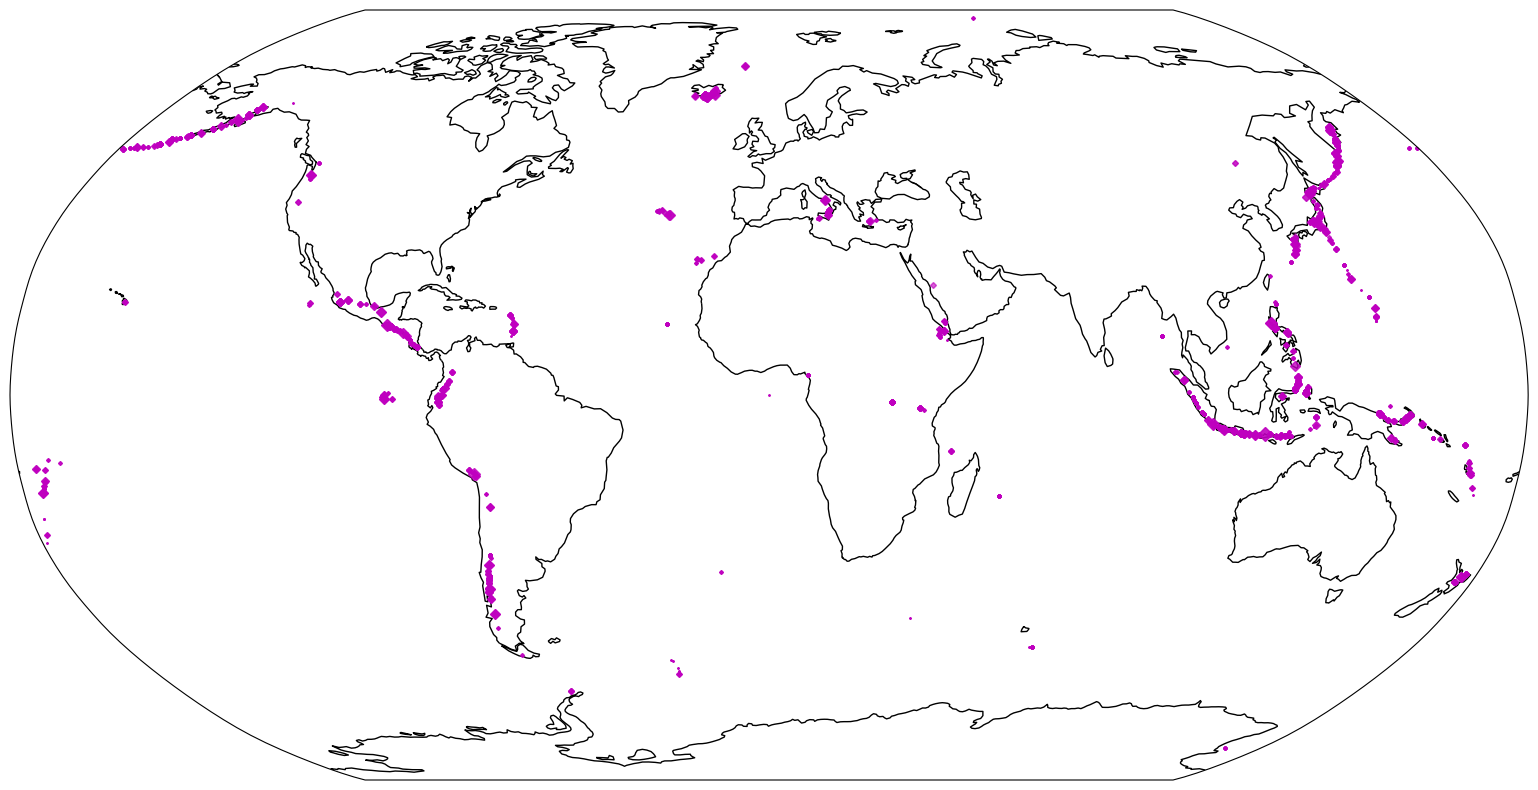

In [17]:
figglobal = plt.figure(figsize=(20,10))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
for volcano in volcanic_eruptions:
    ax.plot(
        volcano.lon_deg,
        volcano.lat_deg,
        'D',
        transform=ccrs.PlateCarree(),
        color='m',
        markersize=1*volcano.VEI,
        alpha=max(0., 1-(dt.datetime.now()-volcano.end_time)/dt.timedelta(days=365*dt.datetime.now().year))
        )


### Communication opportunities

In [18]:
ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

### Add an active eruption now

In [19]:
first_eruption = volcanic_eruptions[0]


min_eruption_time = min_time
max_eruption_time = max_time-dt.timedelta(seconds=2600*6)

active_eruption = Eruption(
    lon_deg=first_eruption.lon_deg,
    lat_deg=first_eruption.lat_deg,
    alt_km=first_eruption.alt_km,
    name=first_eruption.name,
    start_time=min_time,
    end_time=max_eruption_time,
    VEI=first_eruption.VEI,
    )

volcanic_eruptions.append(
    active_eruption
)

In [20]:
sim_times = [min_time]
while sim_times[-1]<= max_time:
    sim_times.append(sim_times[-1]+dt.timedelta(seconds=3600))

wx_request_years = sorted(list(set([f"{sim_time.year:02d}" for sim_time in sim_times])))

wx_request_months = sorted(list(set([f"{sim_time.month:02d}" for sim_time in sim_times])))

wx_request_days = sorted(list(set([f"{sim_time.day:02d}" for sim_time in sim_times])))

wx_request_hours = sorted(list(set([f"{sim_time.hour:02d}:00" for sim_time in sim_times])))

# print(wx_request_years)

# print(wx_request_months)

# print(wx_request_days)

# print(wx_request_years)

lon_deg=first_eruption.lon_deg,
lat_deg=first_eruption.lat_deg,

In [21]:
RELOAD_WX_DATA = False

if RELOAD_WX_DATA:

    dataset_degrees_offset = 2

    dataset = "reanalysis-era5-pressure-levels"
    request = {
        "product_type": ["reanalysis"],
        "variable": [
            "geopotential",
            "u_component_of_wind",
            "v_component_of_wind"
        ],
        "year": wx_request_years,
        "month": wx_request_months,
        "day": wx_request_days,
        "time": wx_request_hours,
        "pressure_level": [
            "1", "2", "3",
            "5", "7", "10",
            "20", "30", "50",
            "70", "100", "125",
            "150", "175", "200",
            "225", "250", "300",
            "350", "400", "450",
            "500", "550", "600",
            "650", "700", "750",
            "775", "800", "825",
            "850", "875", "900",
            "925", "950", "975",
            "1000"
        ],
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [first_eruption.lat_deg+dataset_degrees_offset, first_eruption.lon_deg-dataset_degrees_offset, first_eruption.lat_deg-dataset_degrees_offset, first_eruption.lon_deg+dataset_degrees_offset]
    }

    client = cdsapi.Client()

    datafile = client.retrieve(dataset, request).download()
else:
    if first_eruption.name.startswith("Pinatubo"):
        datafile = "data/4eff2dcd4a0488ca23d335e348a2de10.nc"
    elif first_eruption.name.startswith("Anatahan"):
        datafile = 'data/660b129e1160cc9cd9f7585d04373677.nc'

In [22]:
winds_ds = xr.open_dataset(datafile)

def get_winds_at_lla_m_s(time: dt.datetime, location: Location):
    subset = winds_ds.sel(latitude=location.lat_deg, longitude=location.lon_deg, valid_time = time, method='nearest')
    df = subset.to_dataframe()
    df['altitude'] = df['z']/g0
    nearest_idx = (df['altitude'] - location.alt_km*1e3).abs().idxmin()
    data = df.loc[nearest_idx]
    return (data['u'], data['v'])



In [23]:
get_winds_at_lla_m_s(min_time, active_eruption)

(np.float32(-5.364151), np.float32(1.5859375))

#### ...and a plume to go with it

Every thirty minutes, spawn a new Event. Move it with the wind.

In [24]:
deltat_plume = dt.timedelta(seconds=1800)

plume_times = [min_eruption_time + deltat_plume*i for i in range(math.ceil((max_eruption_time-min_eruption_time)/deltat_plume))]

plume_tracers = {pt: [] for pt in plume_times}
# https://www.sciencedirect.com/science/article/pii/000469817190028X
# https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2012JB009592


def plume_height_by_vei(vei: float):
    # A.L. Dabrowa, D.N. Green, A.C. Rust, and J.C. Phillips. A global
    # study of volcanic infrasound characteristics and the potential for long-
    # range monitoring. Earth and Planetary Science Letters, 310(3):369–379,
    # 2011.
    altitude_by_vei = [(0, 0.05), (1, 0.6), (2, 3), (3, 9), (4, 17.5), (5, 27.5), (6, 35),]
    return np.interp(vei, [veis for (veis, altitudes) in altitude_by_vei], [altitudes for (veis, altitudes) in altitude_by_vei])

max_plume_height = plume_height_by_vei(active_eruption.VEI)

for plume_time_index, plume_time in enumerate(plume_times):


    # Propagate the previous plume tracers
    if plume_time_index>0:
        previous_plumes = plume_tracers[plume_times[plume_time_index-1]]
        for previous_plume in previous_plumes:
            
            time_since_eruption_start = plume_time - active_eruption.start_time
            new_altitude = active_eruption.alt_km + (max_plume_height-active_eruption.alt_km)*np.exp(time_since_eruption_start.total_seconds()/3600.)

            wind_uv_ms = get_winds_at_lla_m_s(plume_time, Location(lon_deg = previous_plume.lon_deg, lat_deg=previous_plume.lat_deg, alt_km=previous_plume.alt_km))
                        

            dy_km = wind_uv_ms[0]*deltat_plume.total_seconds()/1e3 # E-W
            dx_km = wind_uv_ms[1]*deltat_plume.total_seconds()/1e3 # N-S

            dlat_rad = dy_km/R_earth_km
            dlon_rad = dx_km/(R_earth_km*np.cos(previous_plume.lat_deg*math.pi/180.))

            new_lat_deg = previous_plume.lat_deg + dlat_rad*180./math.pi
            new_lon_deg = previous_plume.lon_deg + dlon_rad*180./math.pi

            propagated_plume = Phenomenon(
                lon_deg = new_lon_deg,
                lat_deg=new_lat_deg,
                alt_km=new_altitude,
                name=previous_plume.name,
                start_time=plume_time,
                end_time=plume_time+deltat_plume,
                )
            plume_tracers[plume_time].append(propagated_plume)

    # Create a new plume tracer at the volcano mouth
    new_plume = Phenomenon(
        name=f"Plume {active_eruption.name}",
        lon_deg=active_eruption.lon_deg,
        lat_deg=active_eruption.lat_deg,
        alt_km=active_eruption.alt_km,
        start_time=plume_time,
        end_time=plume_time+deltat_plume,
        )

    plume_tracers[plume_time].append(new_plume)


C:\Users\davidf\AppData\Local\Temp\ipykernel_27460\1672347024.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figglobal = plt.figure(figsize=(20,10))


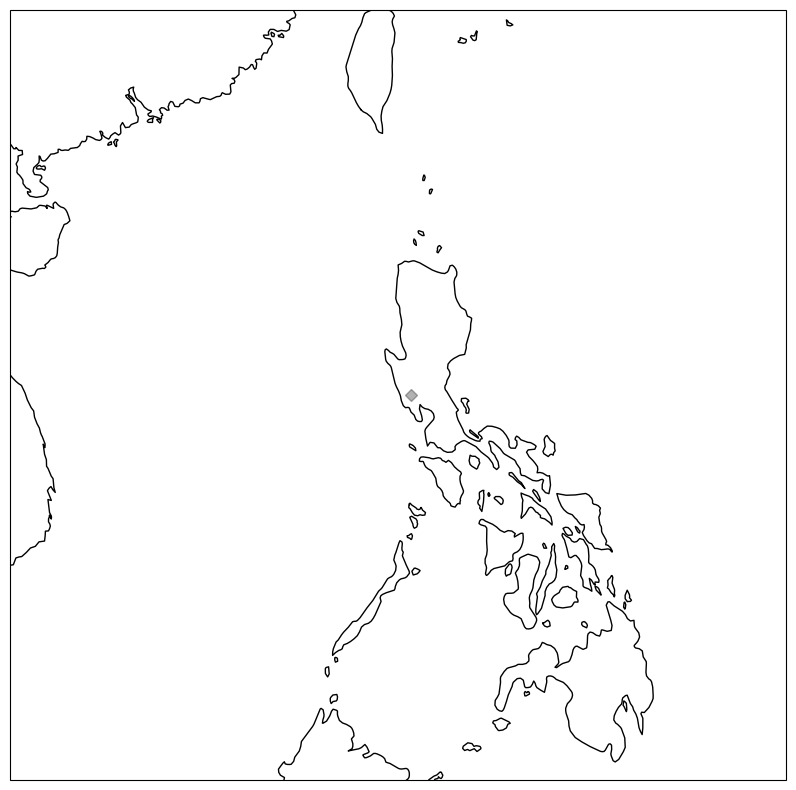

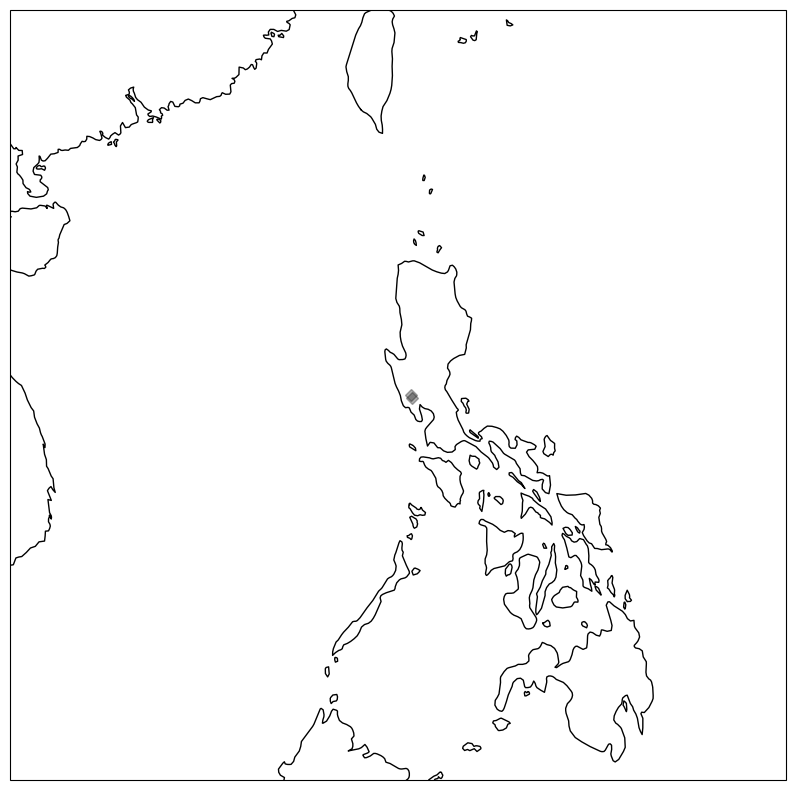

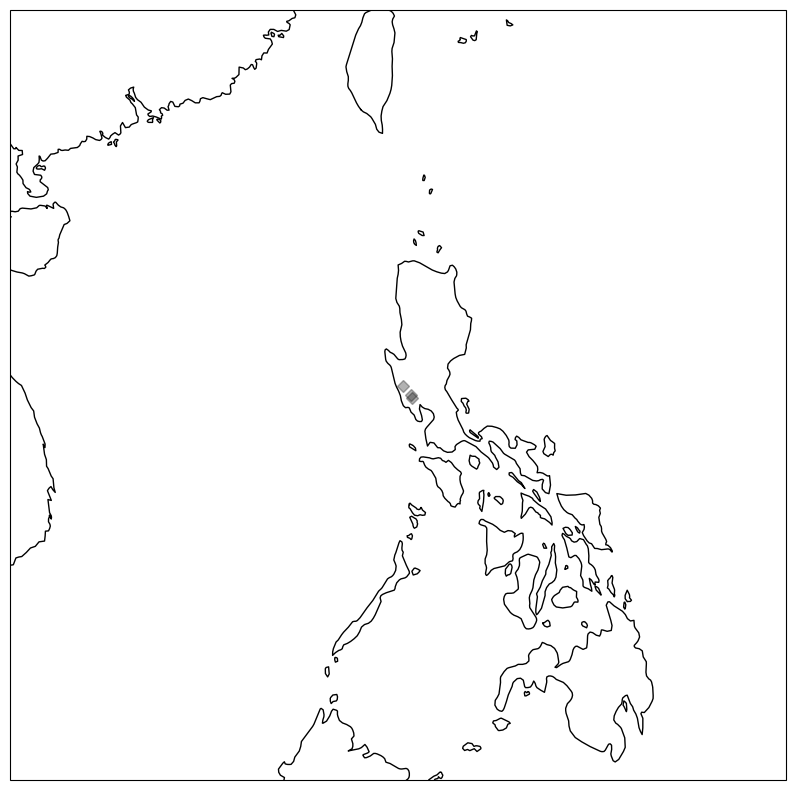

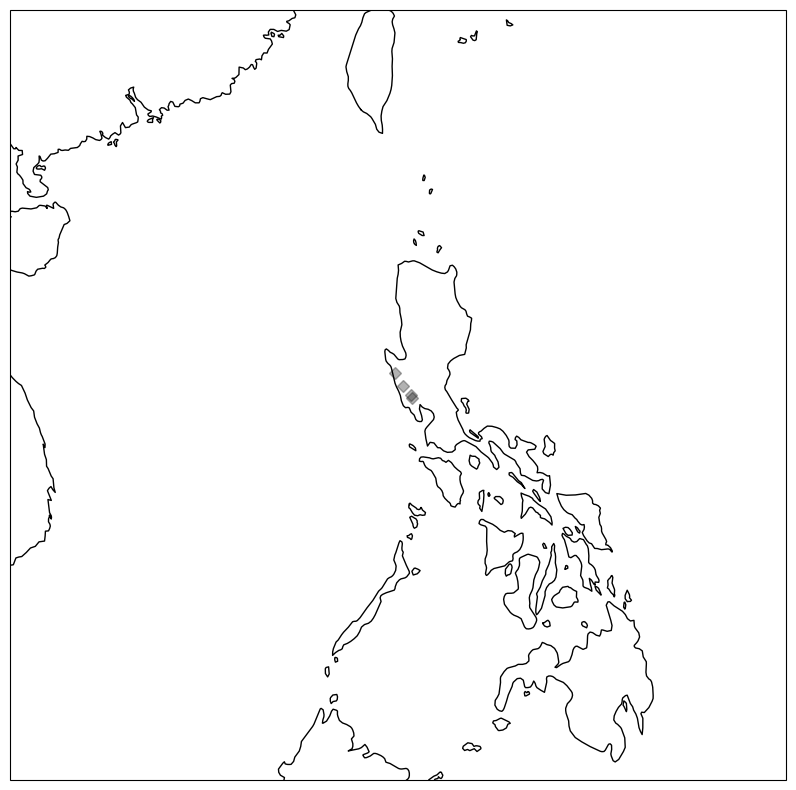

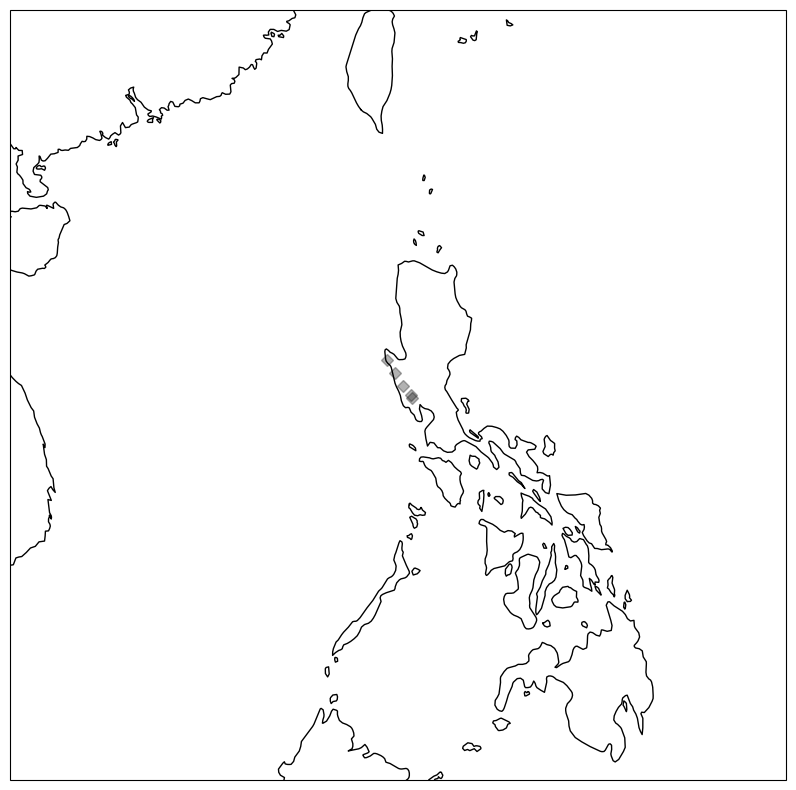

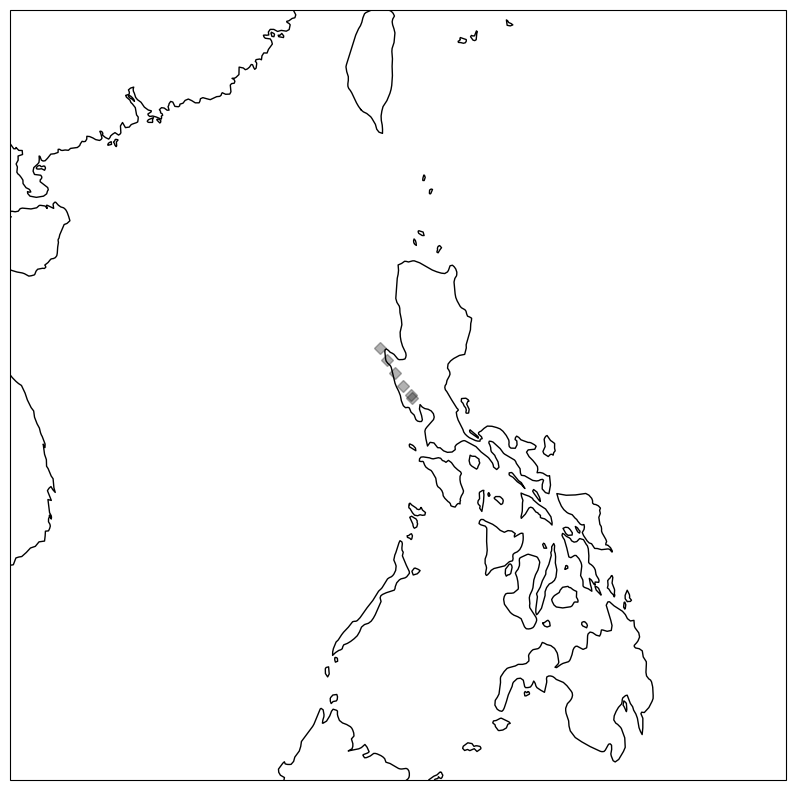

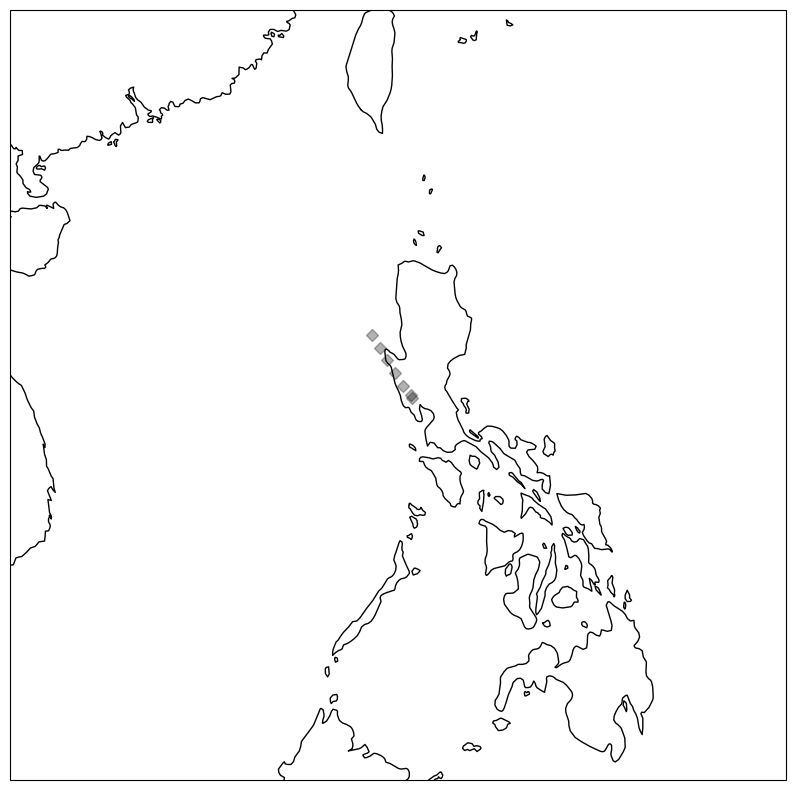

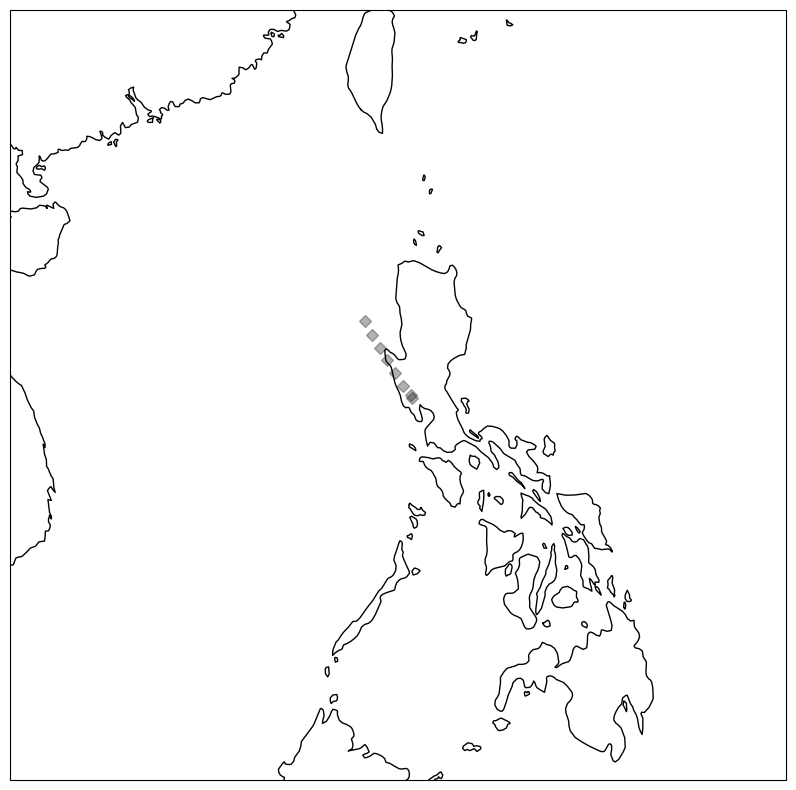

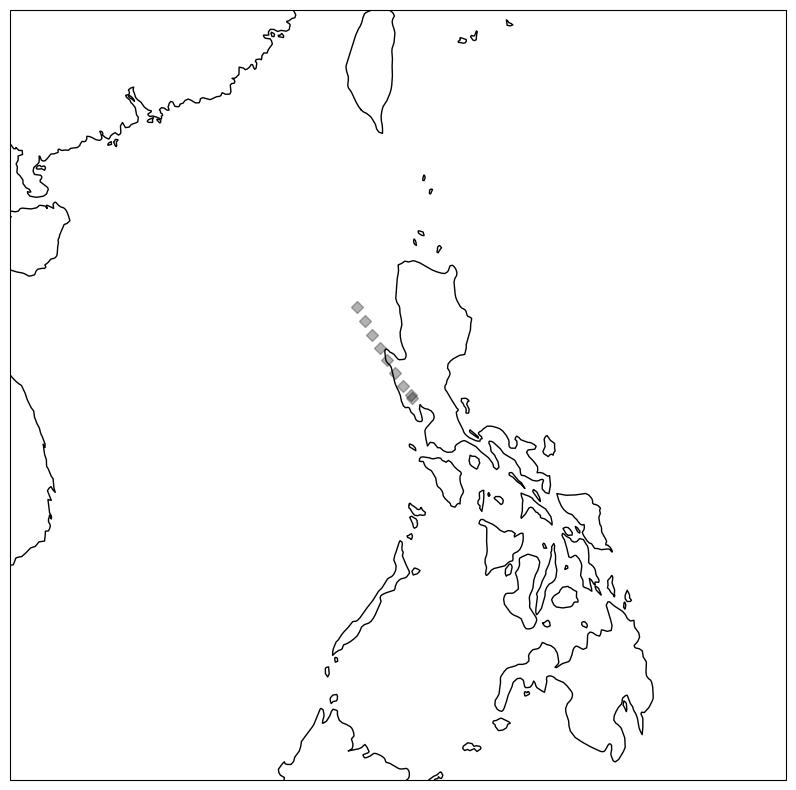

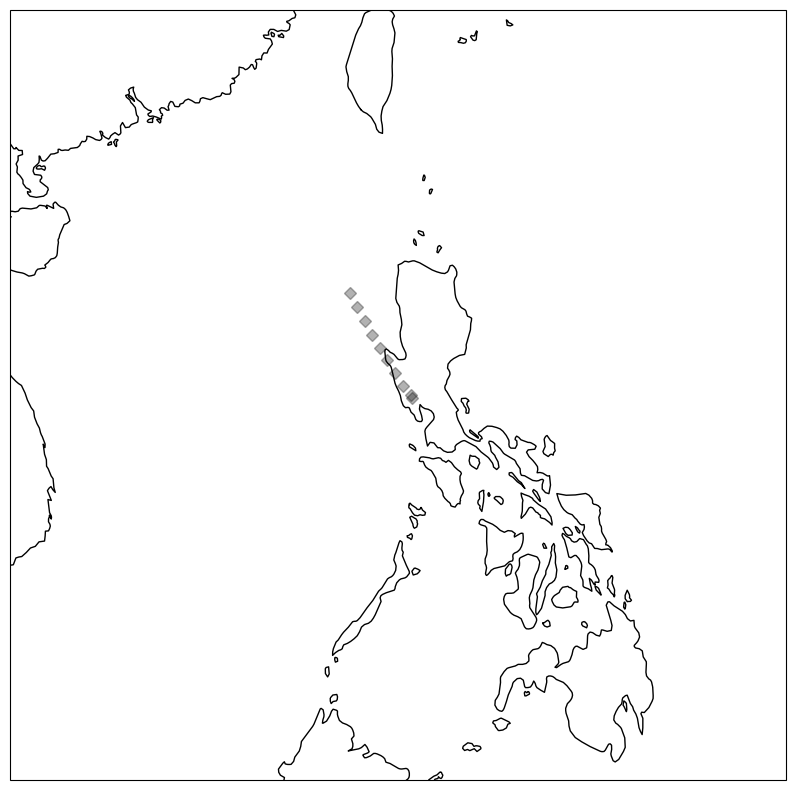

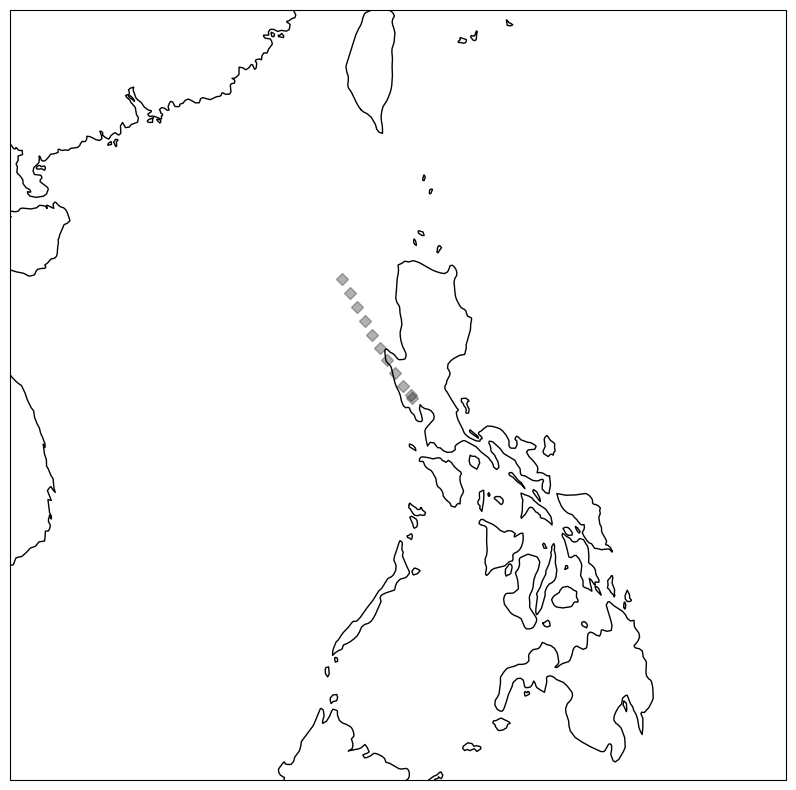

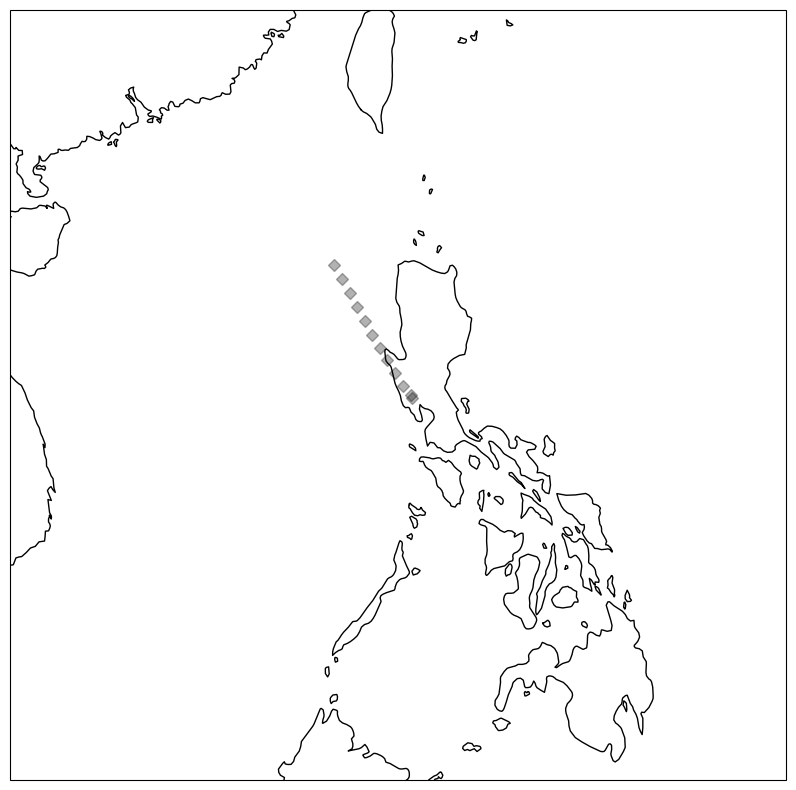

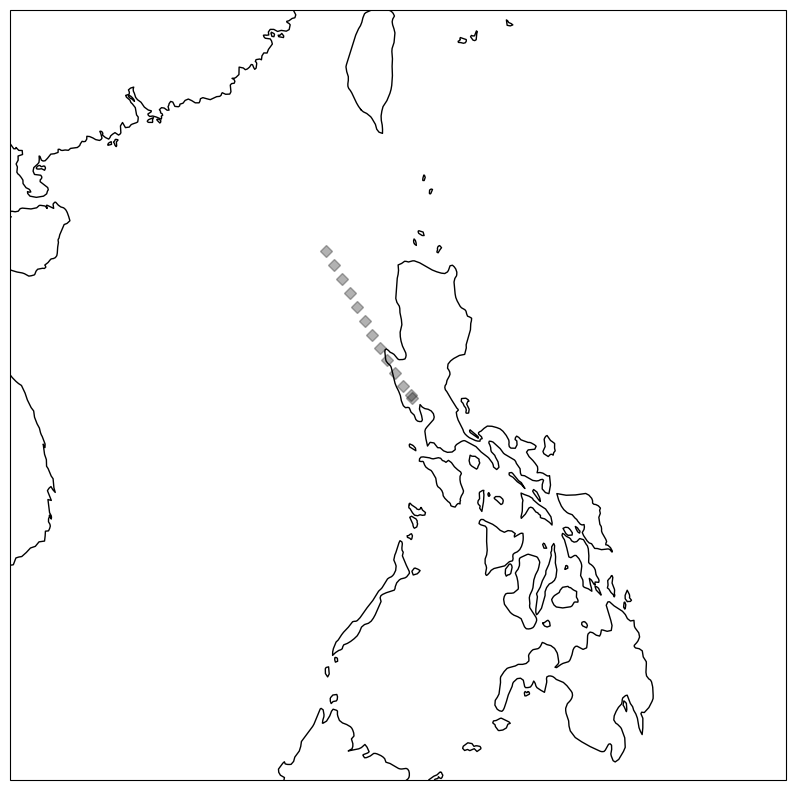

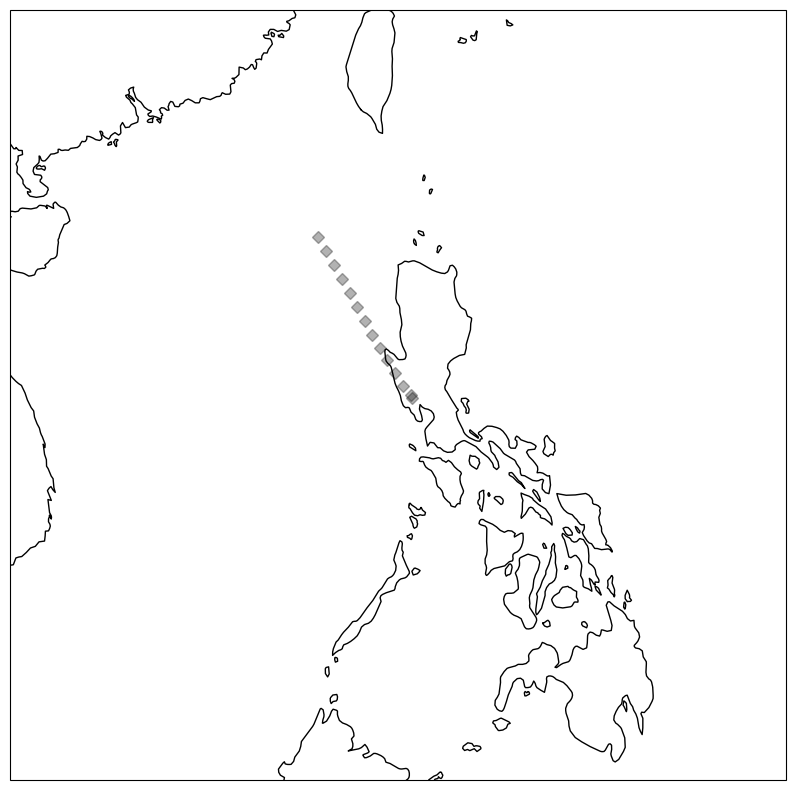

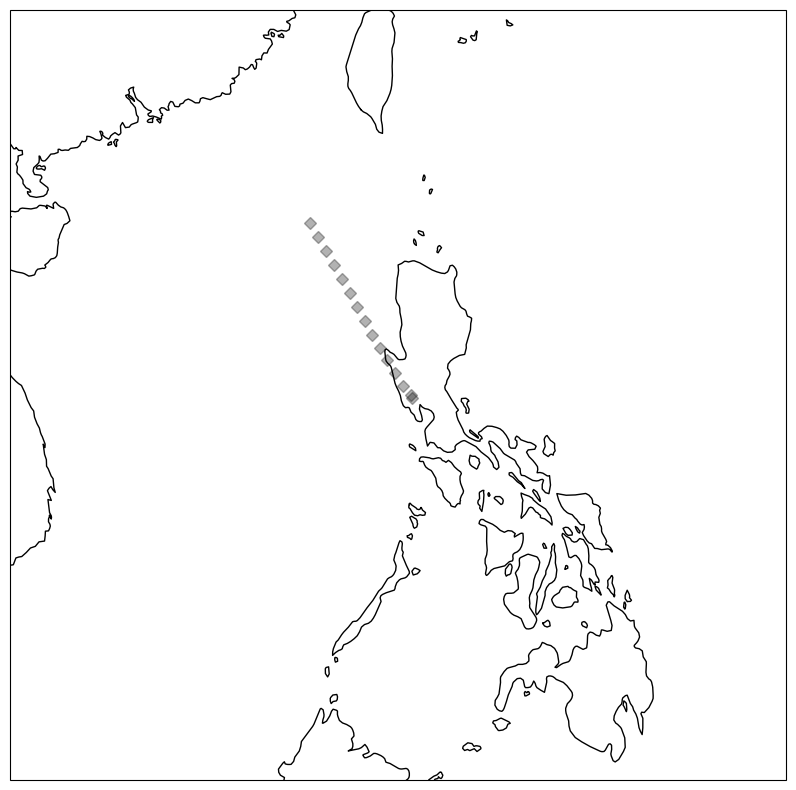

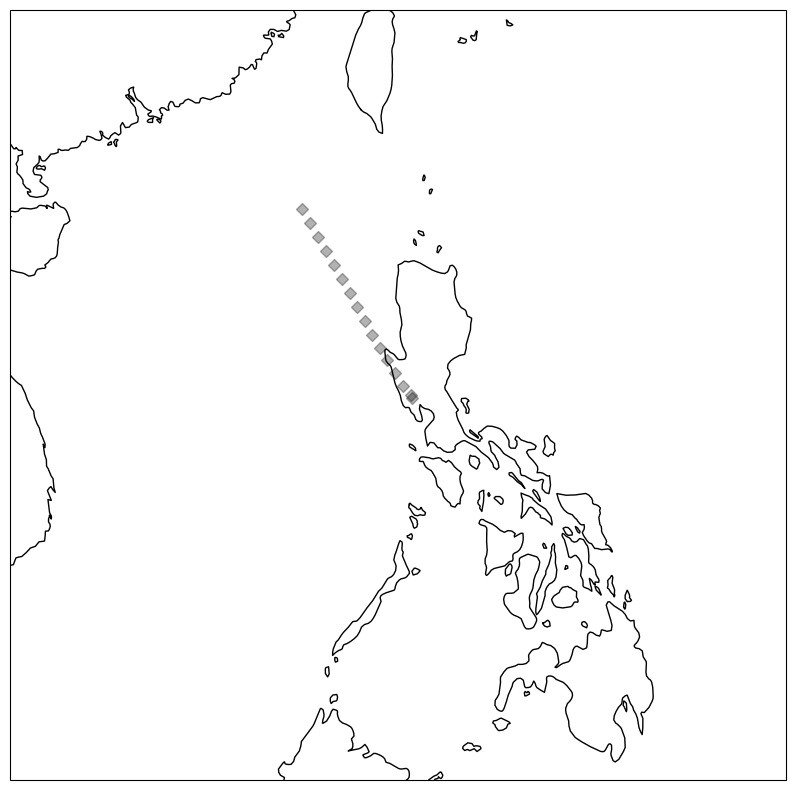

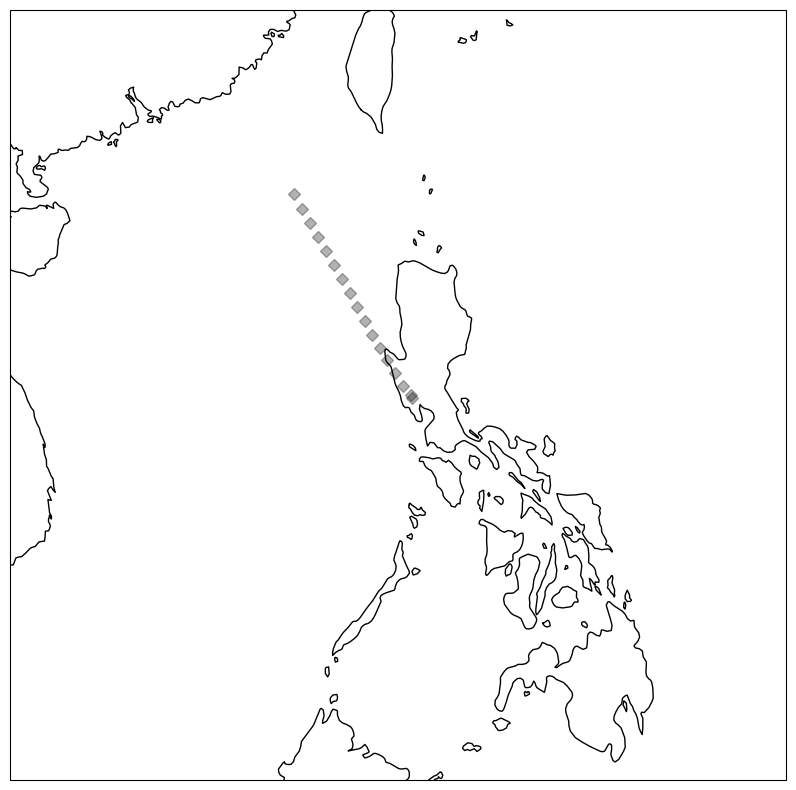

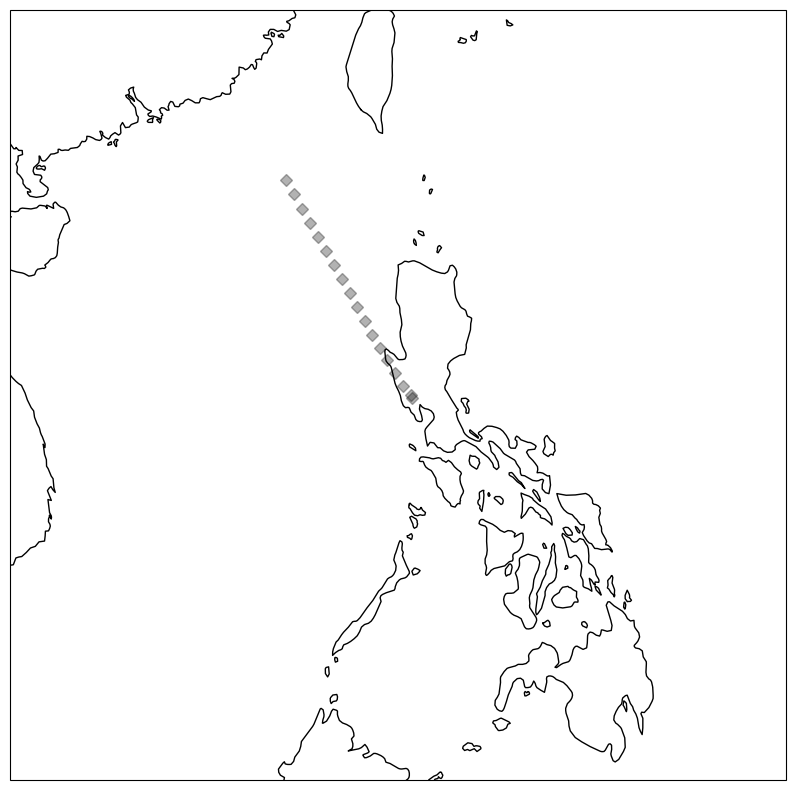

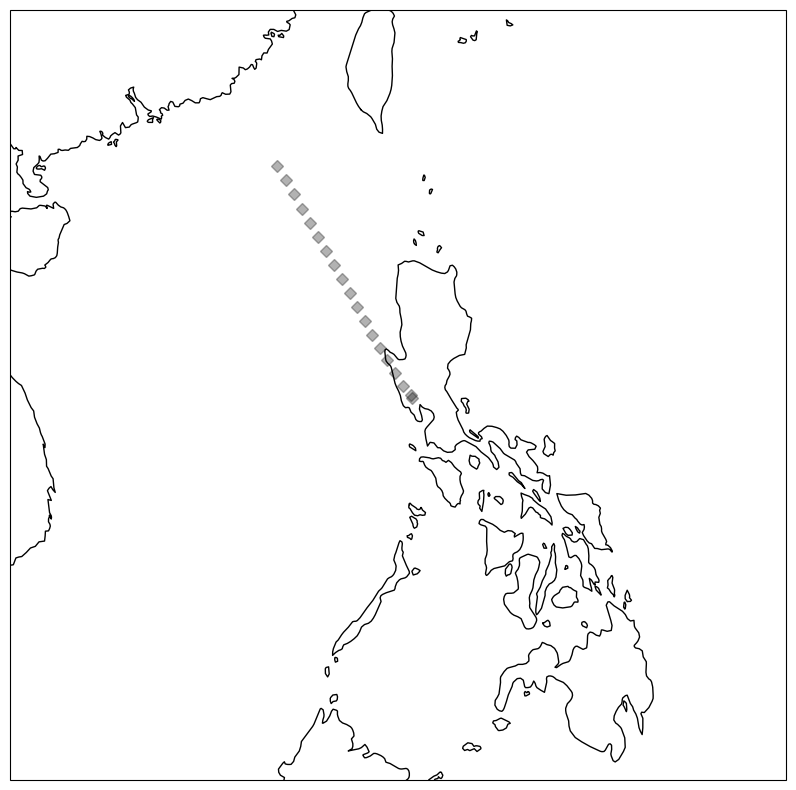

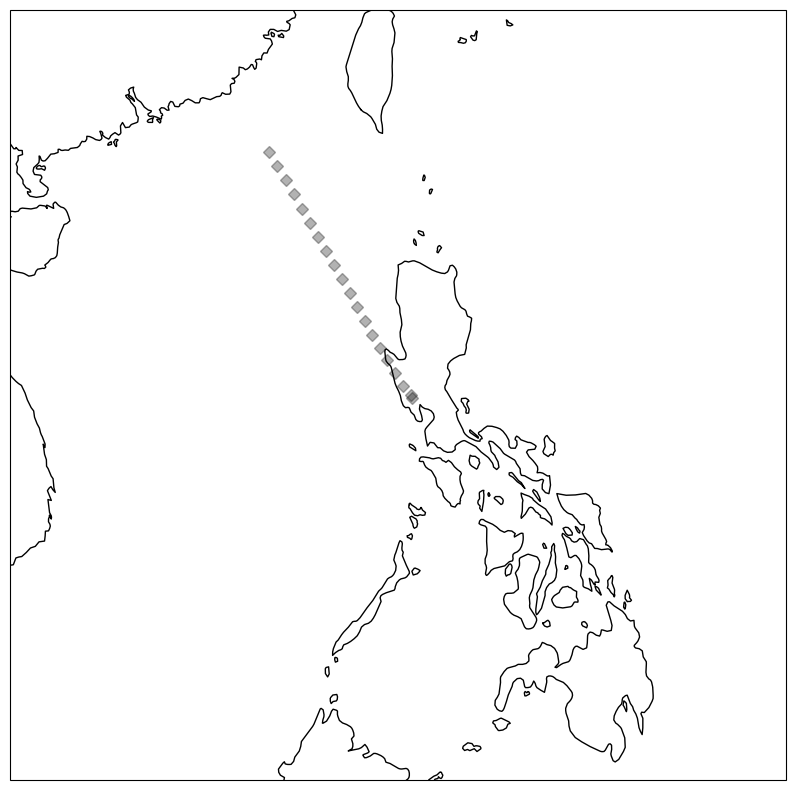

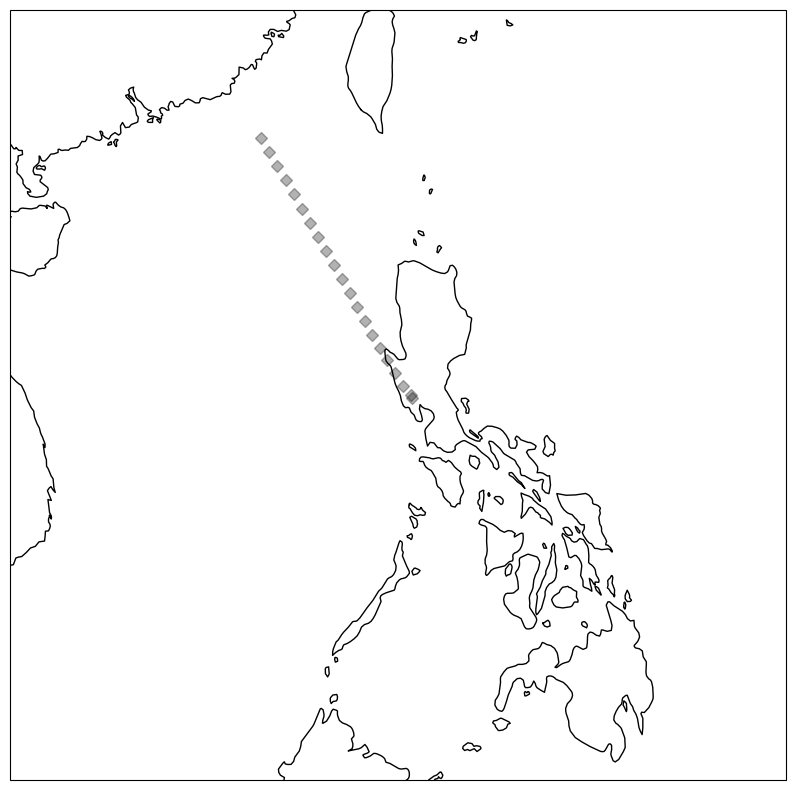

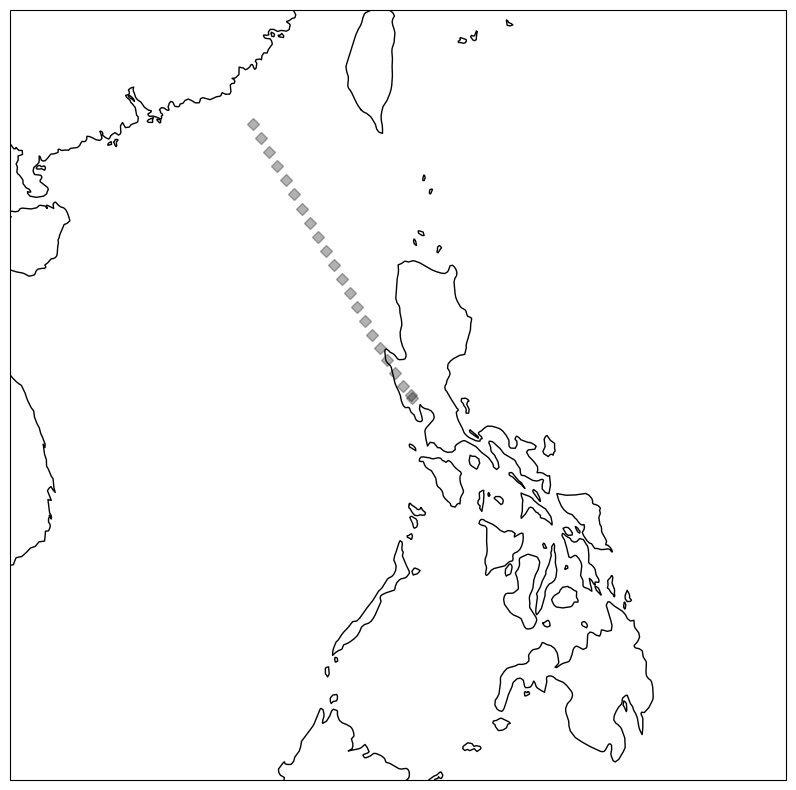

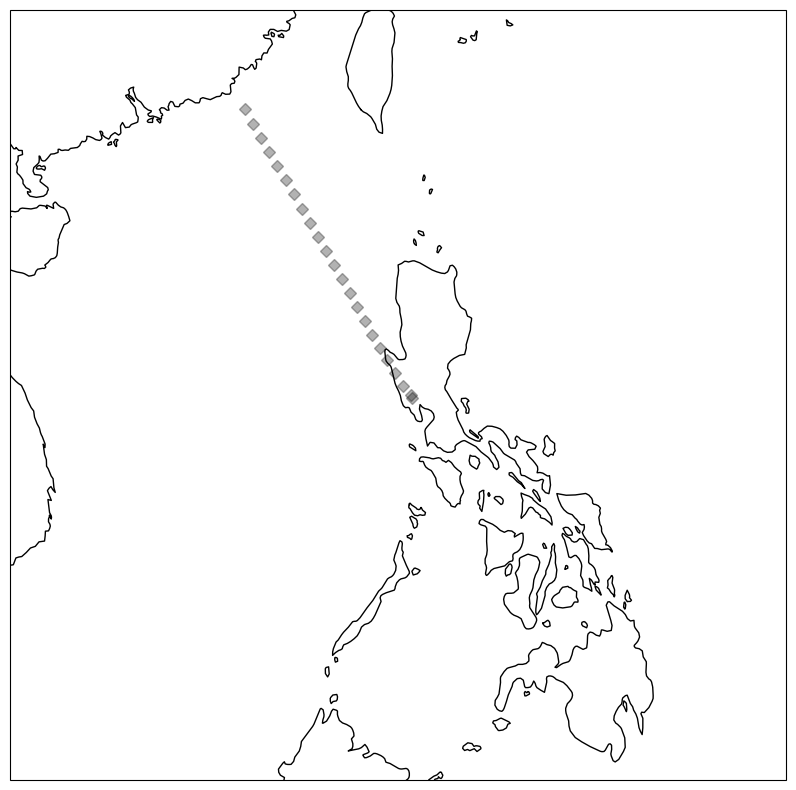

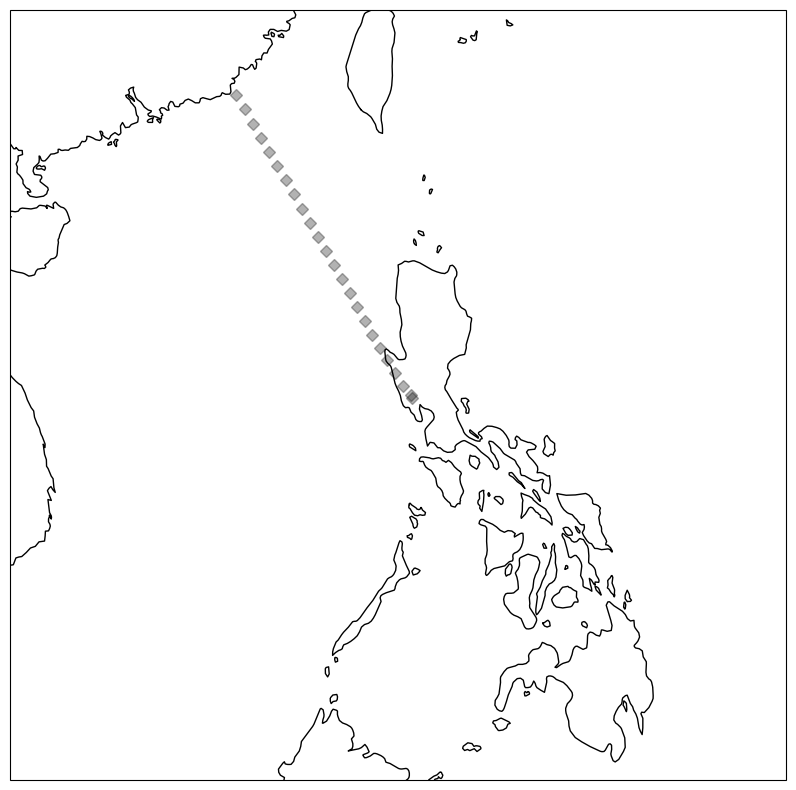

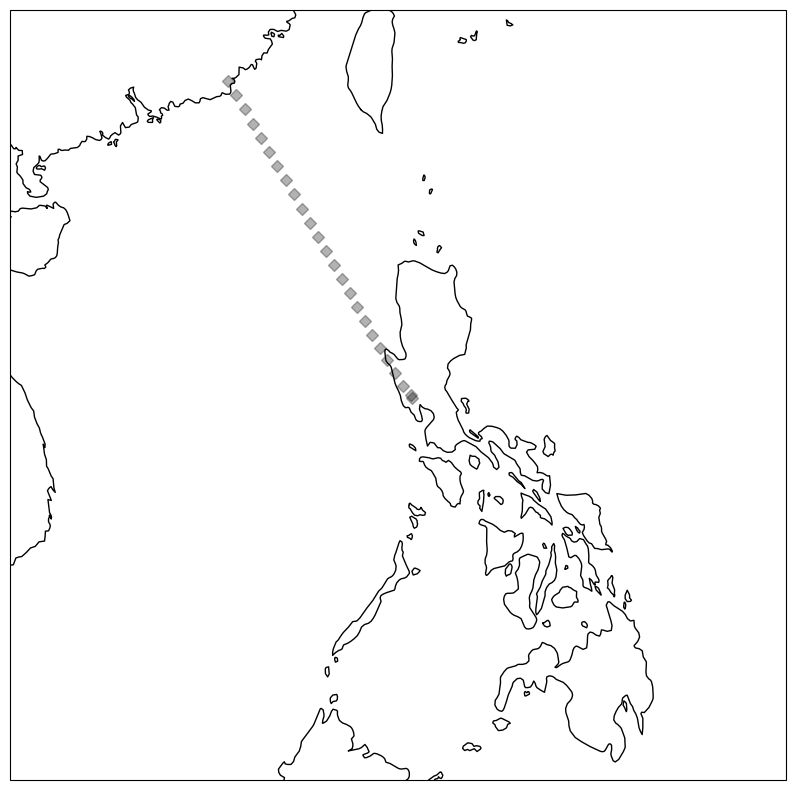

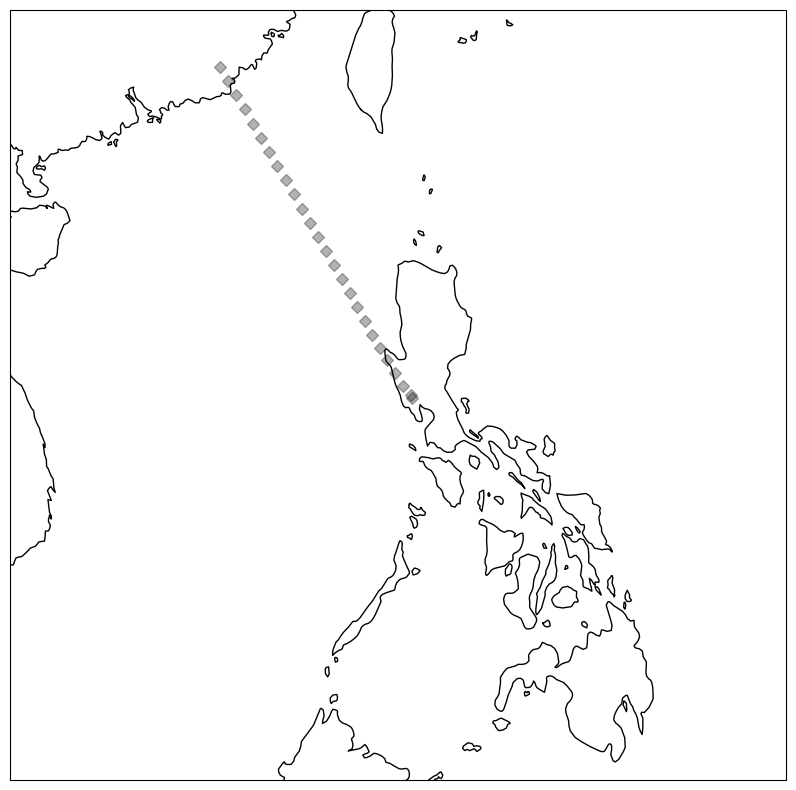

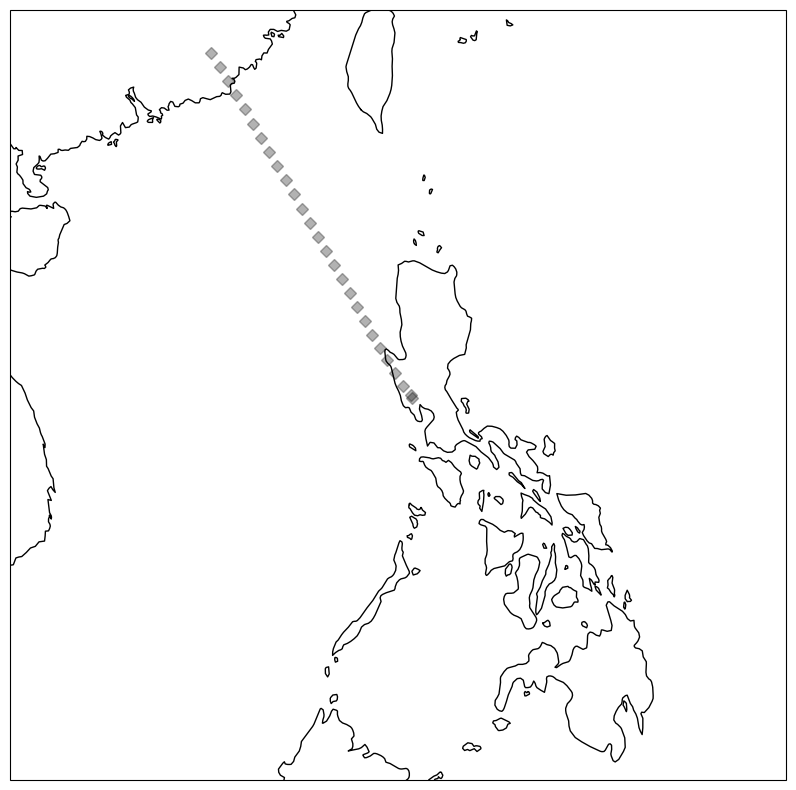

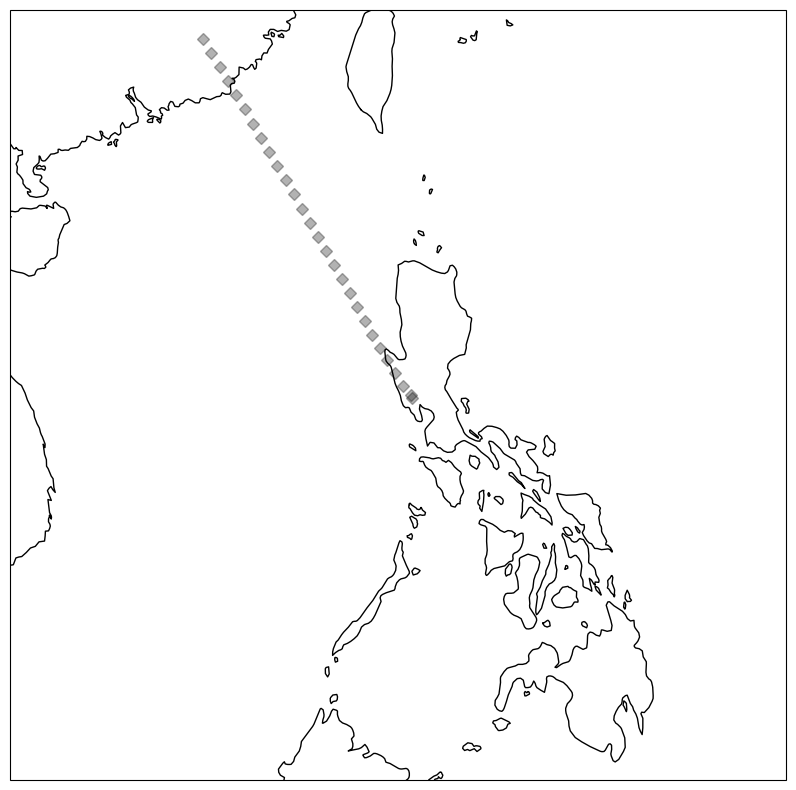

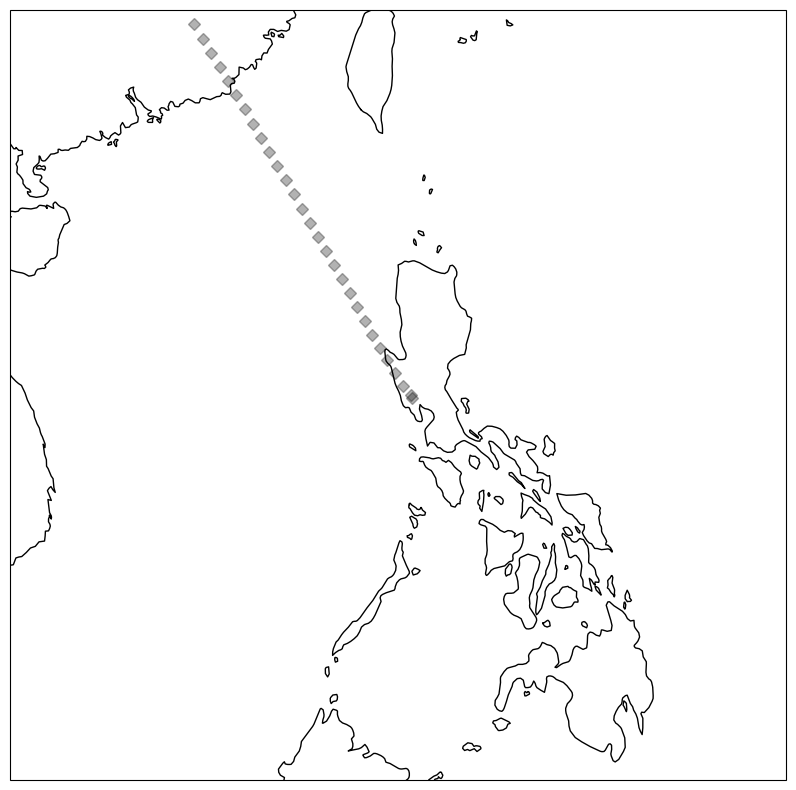

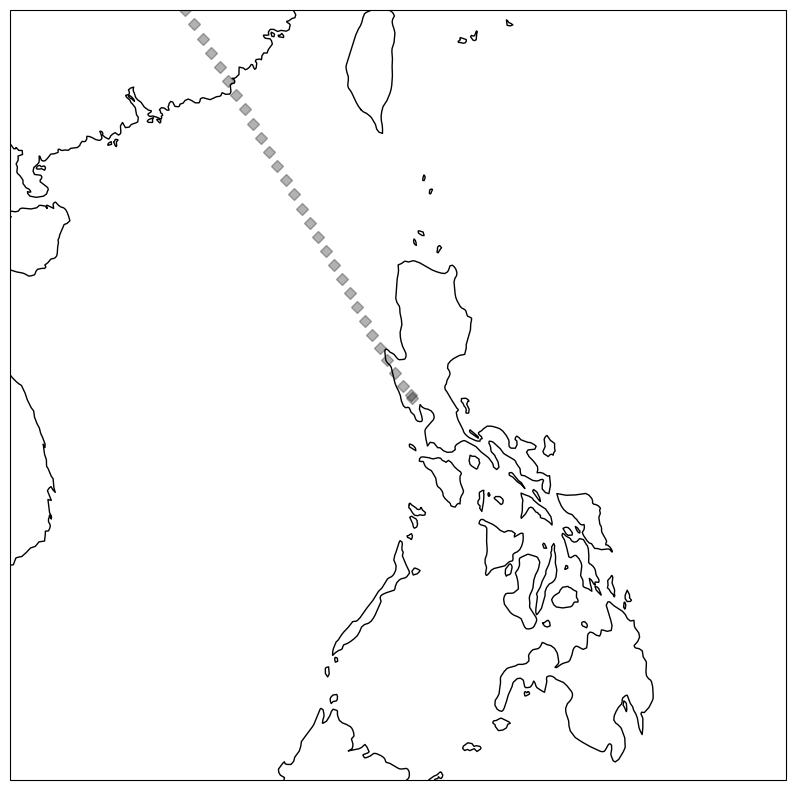

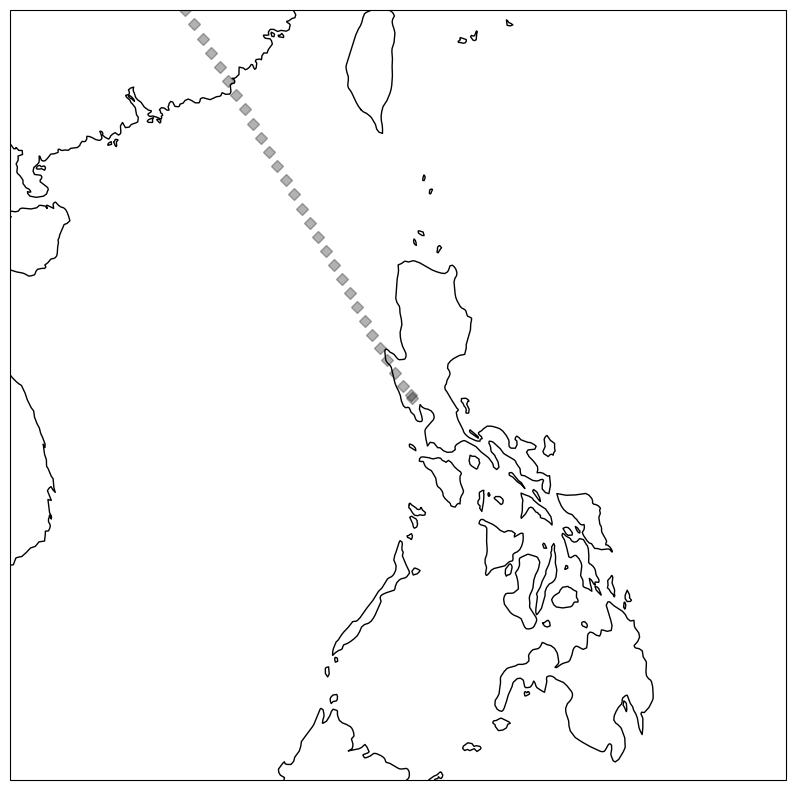

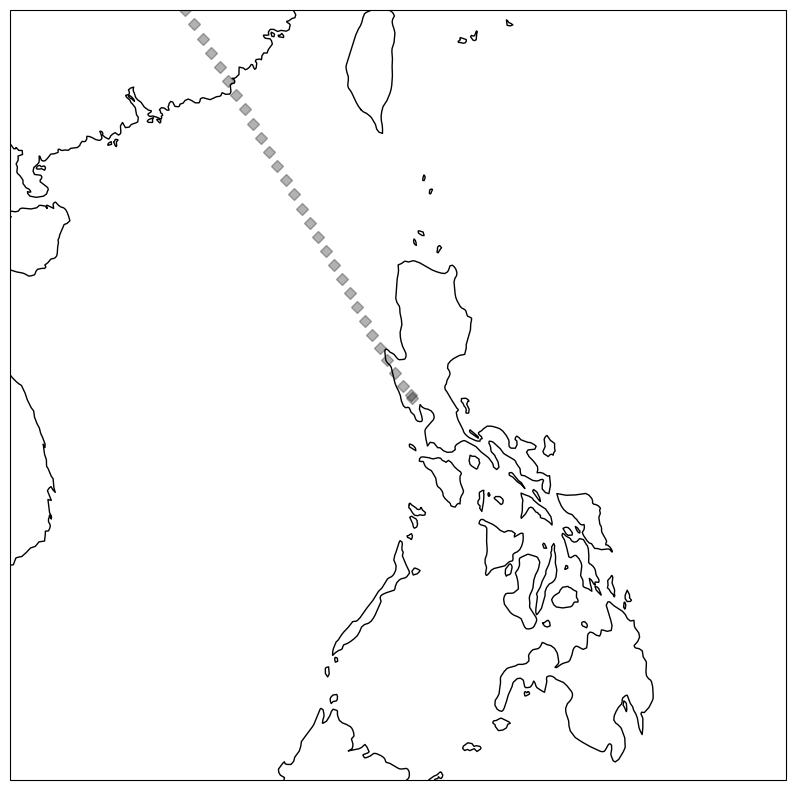

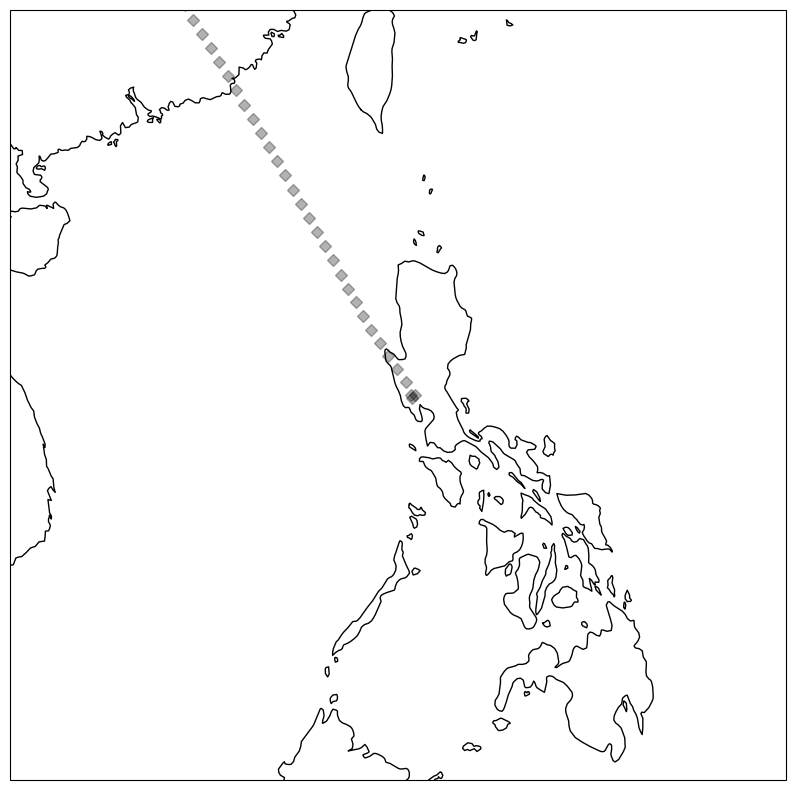

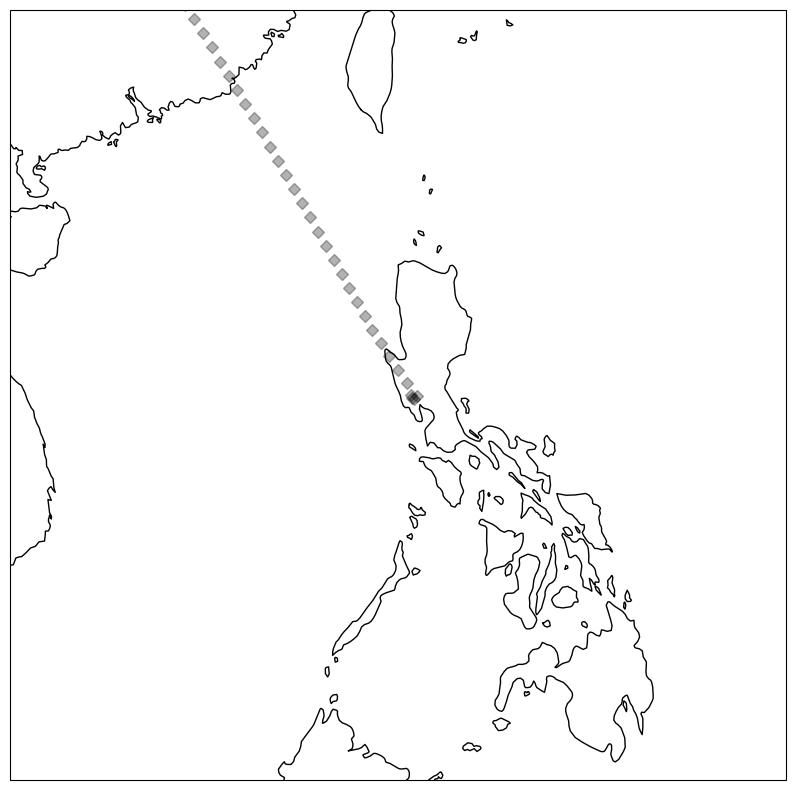

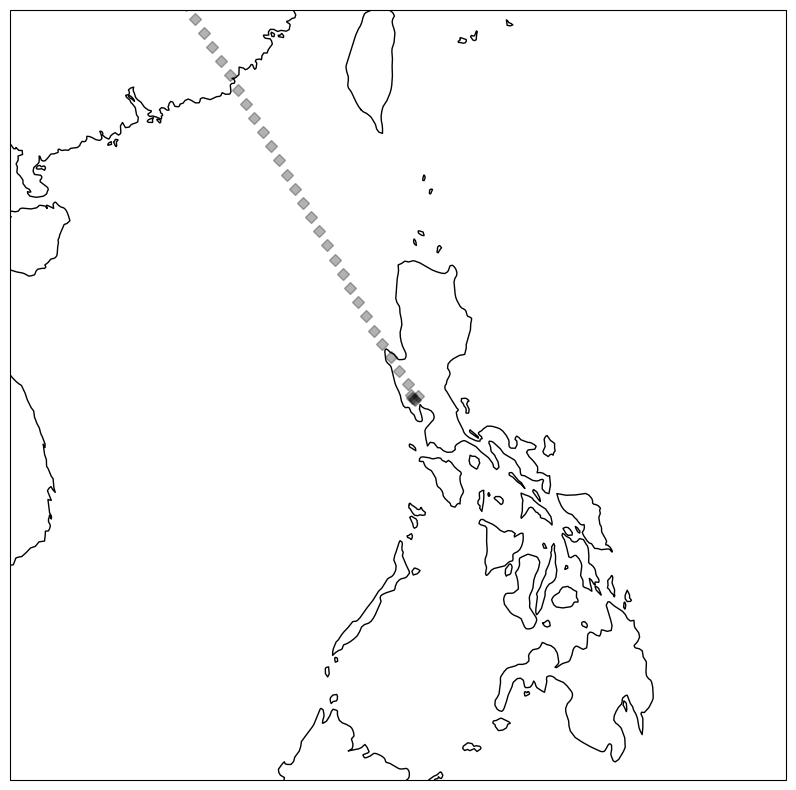

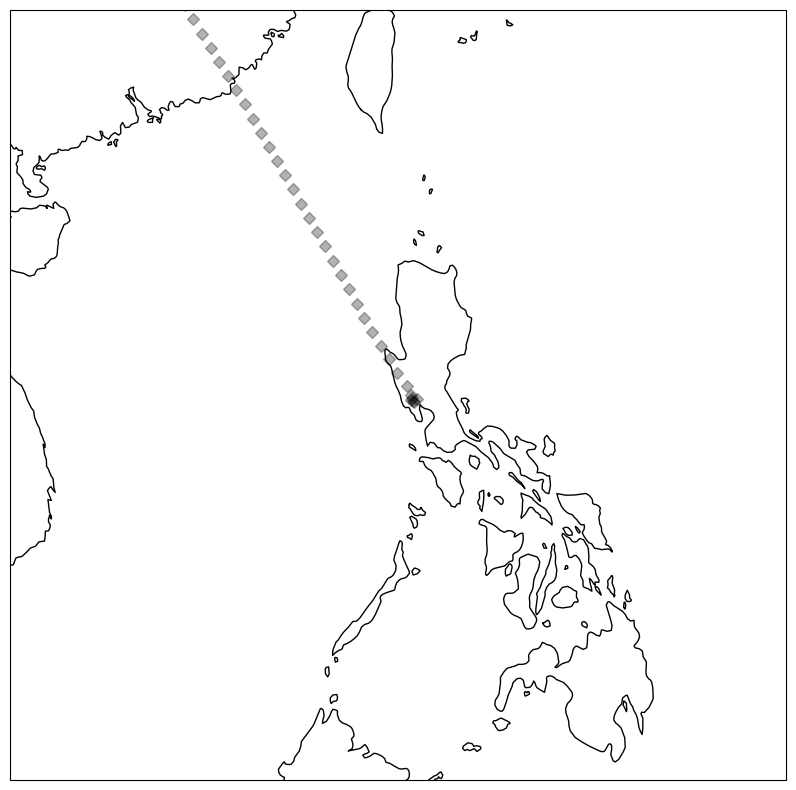

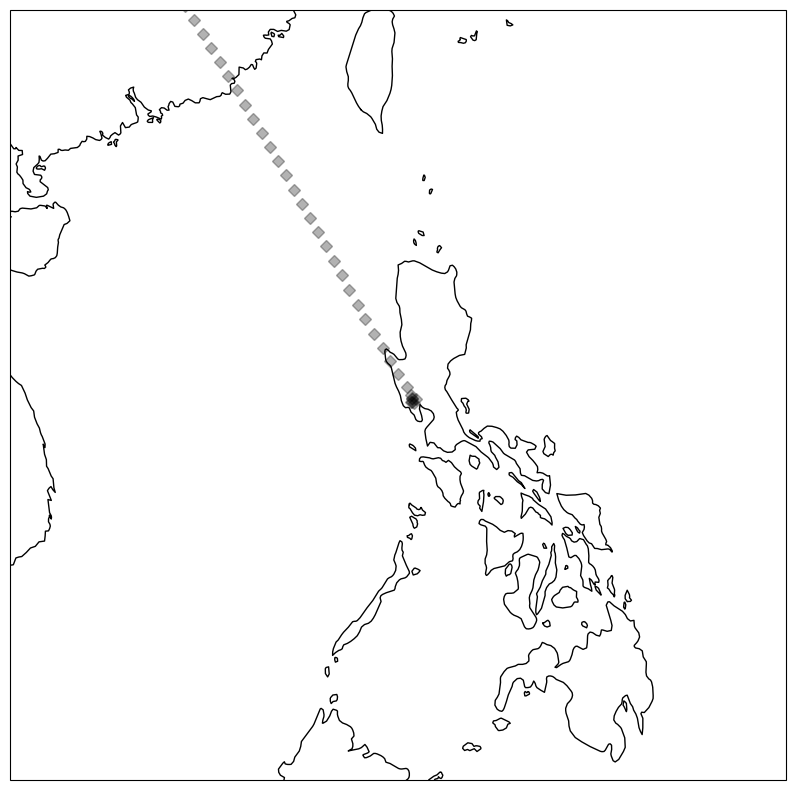

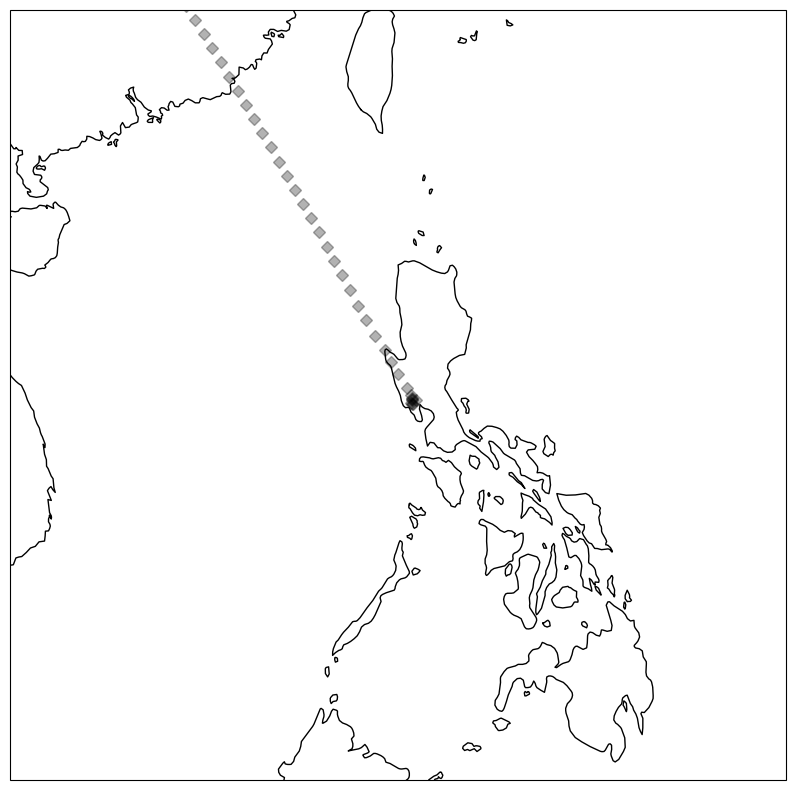

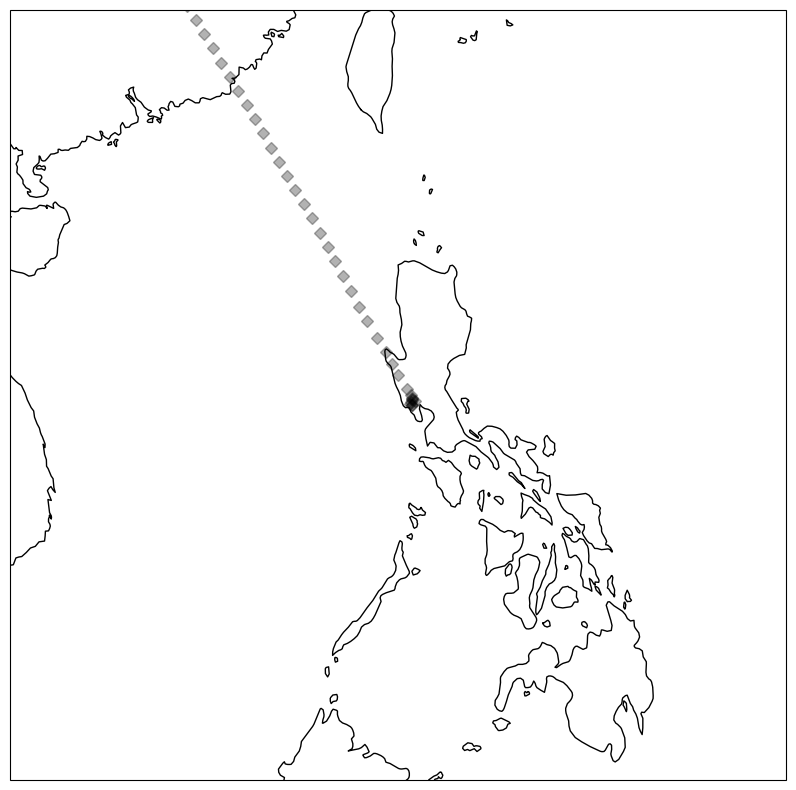

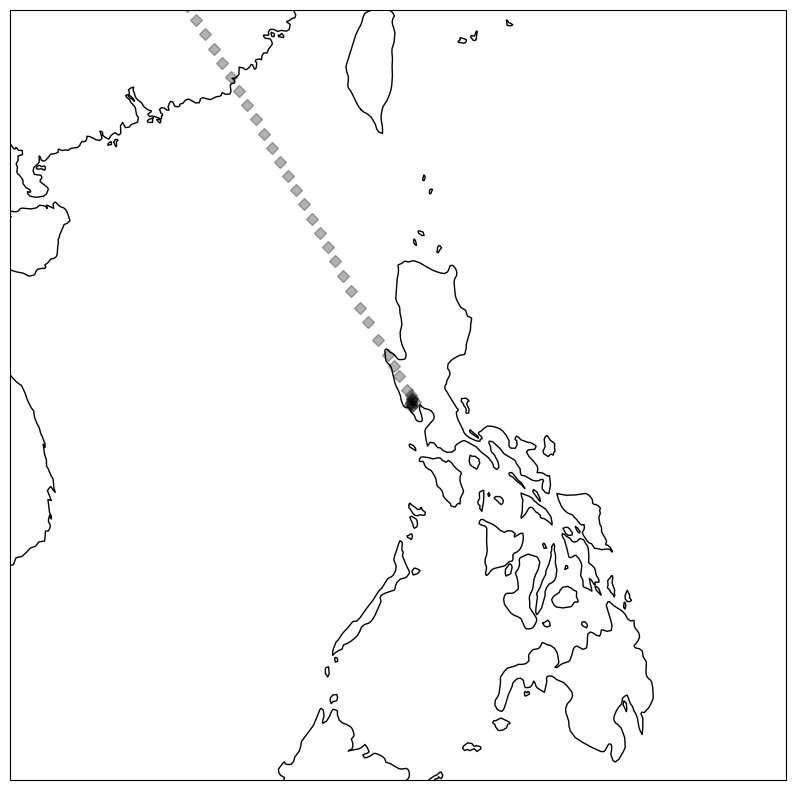

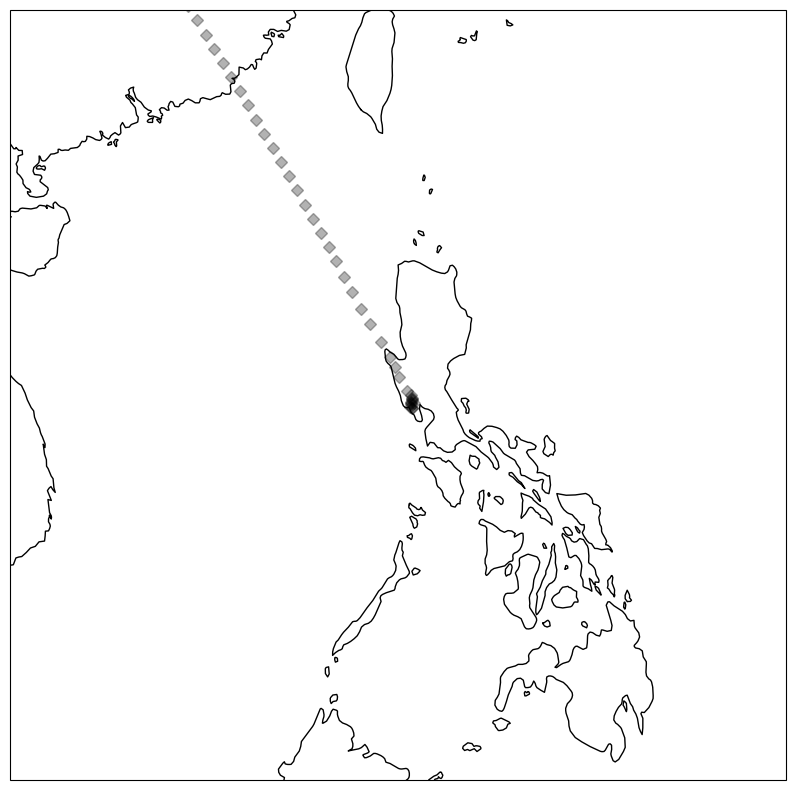

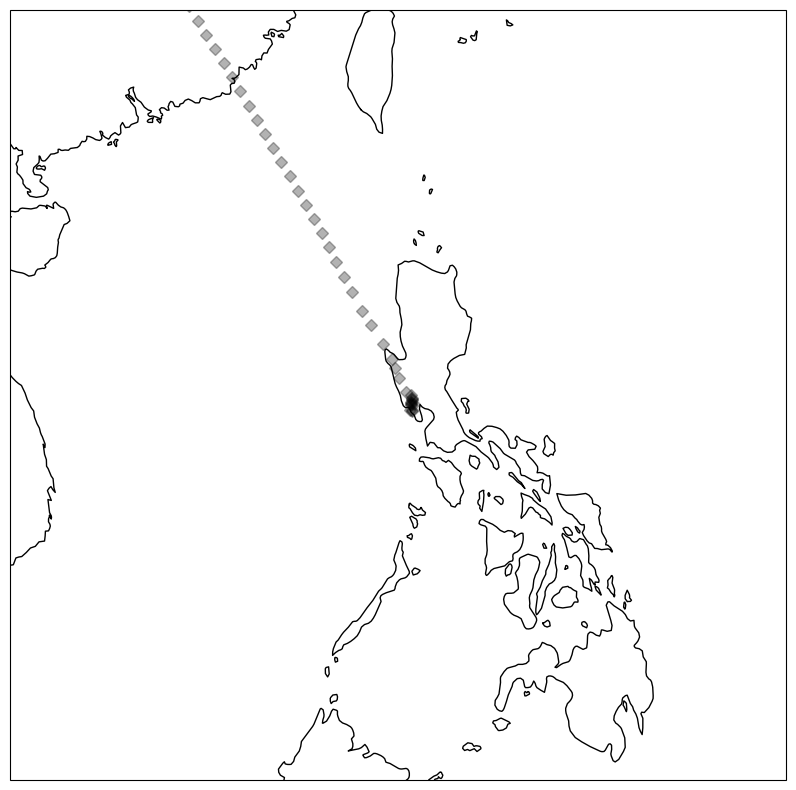

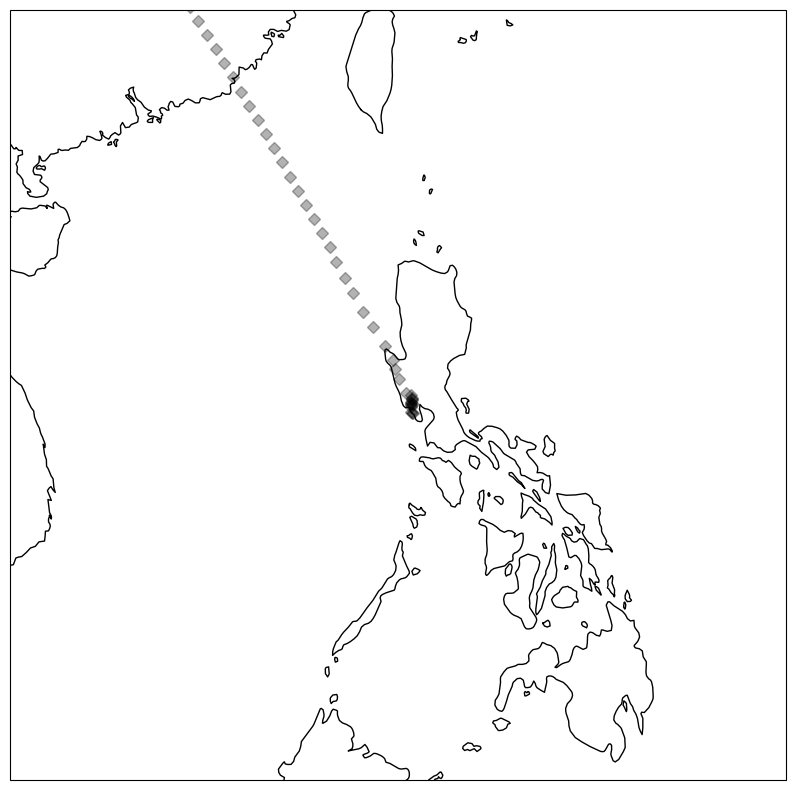

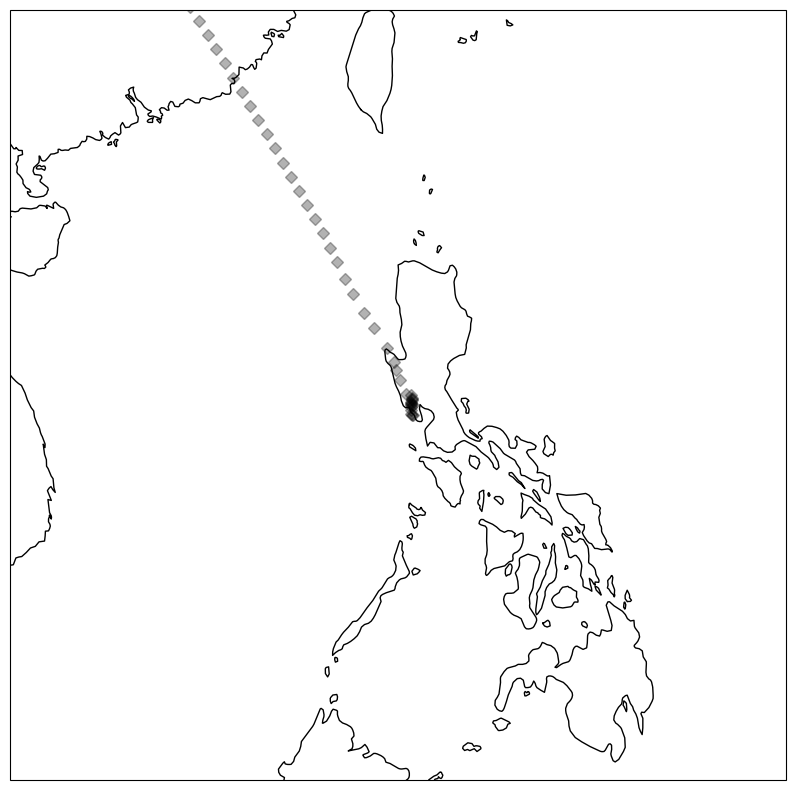

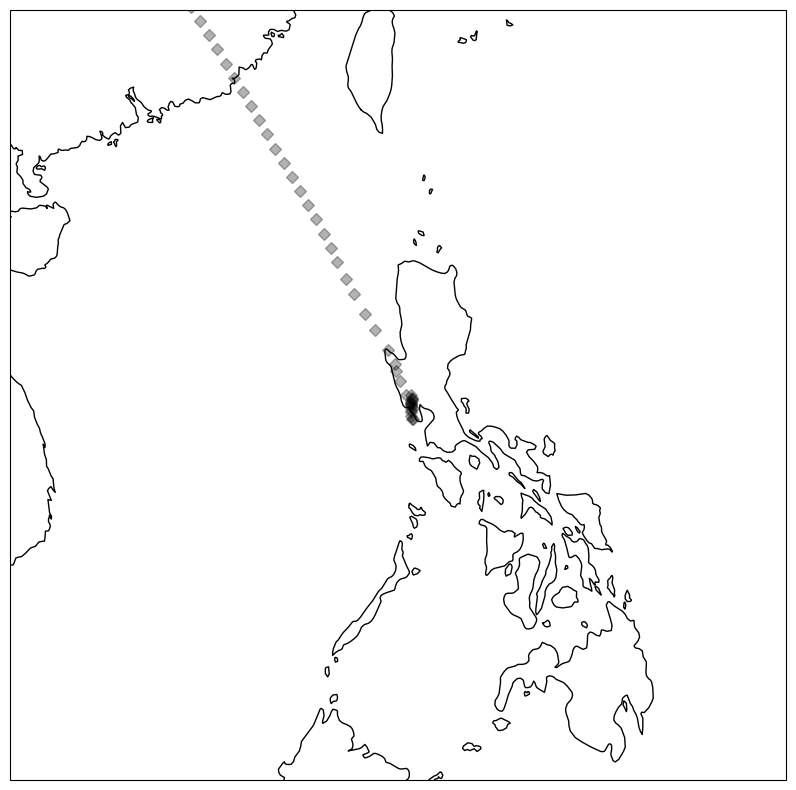

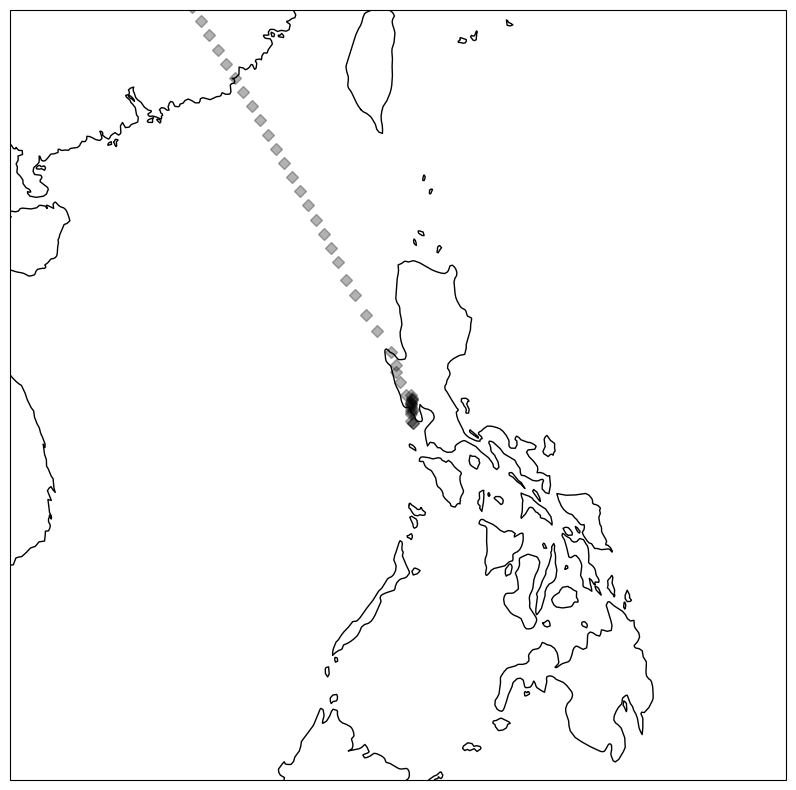

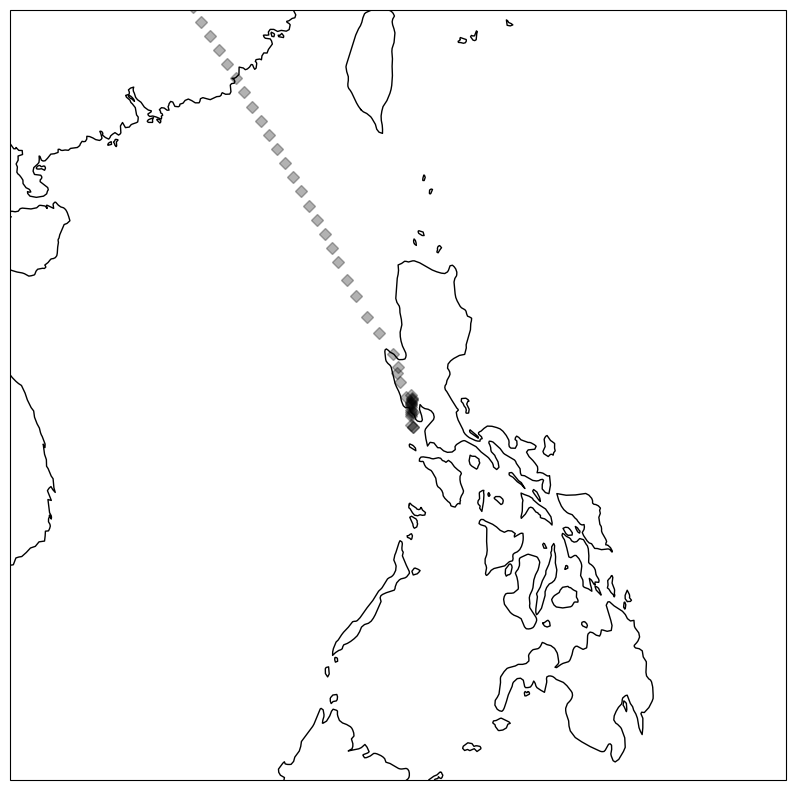

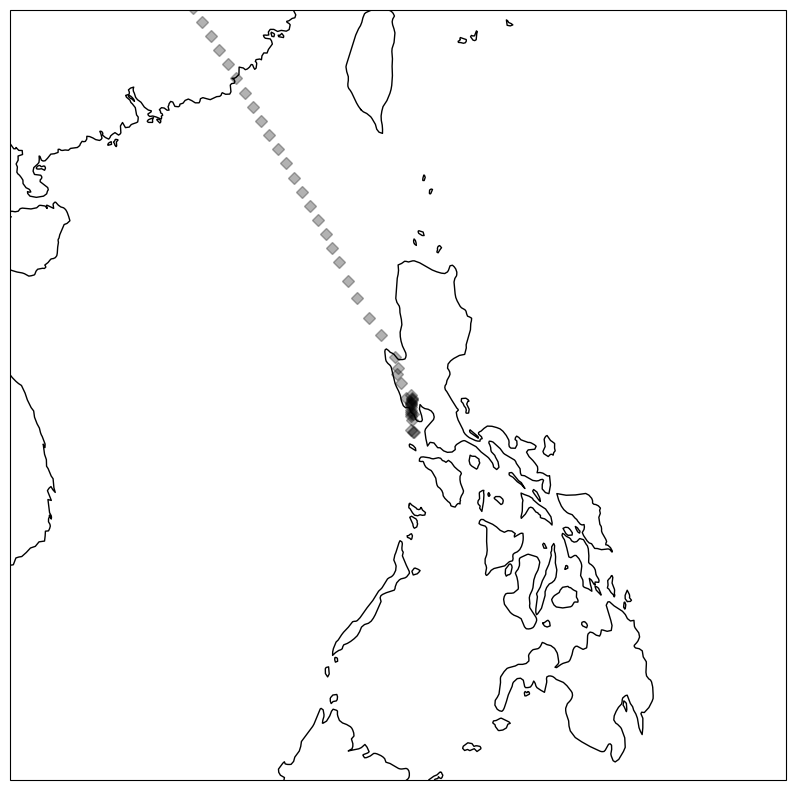

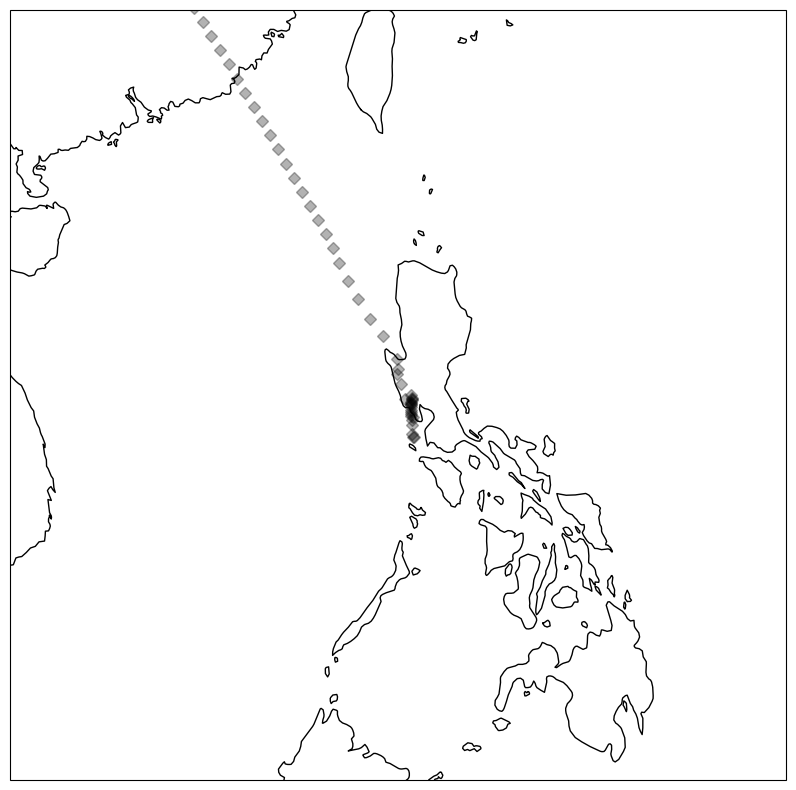

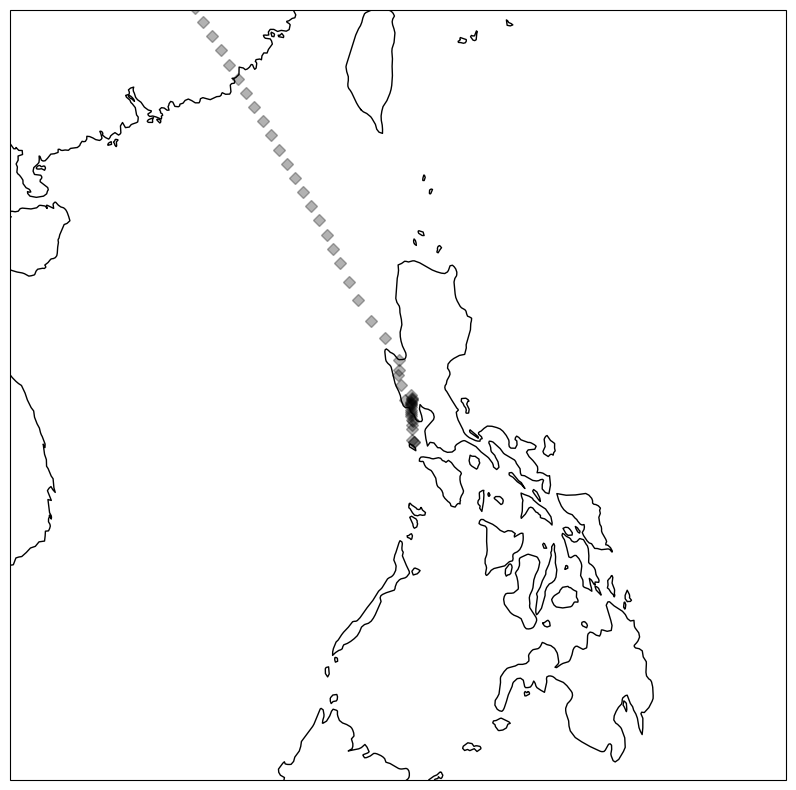

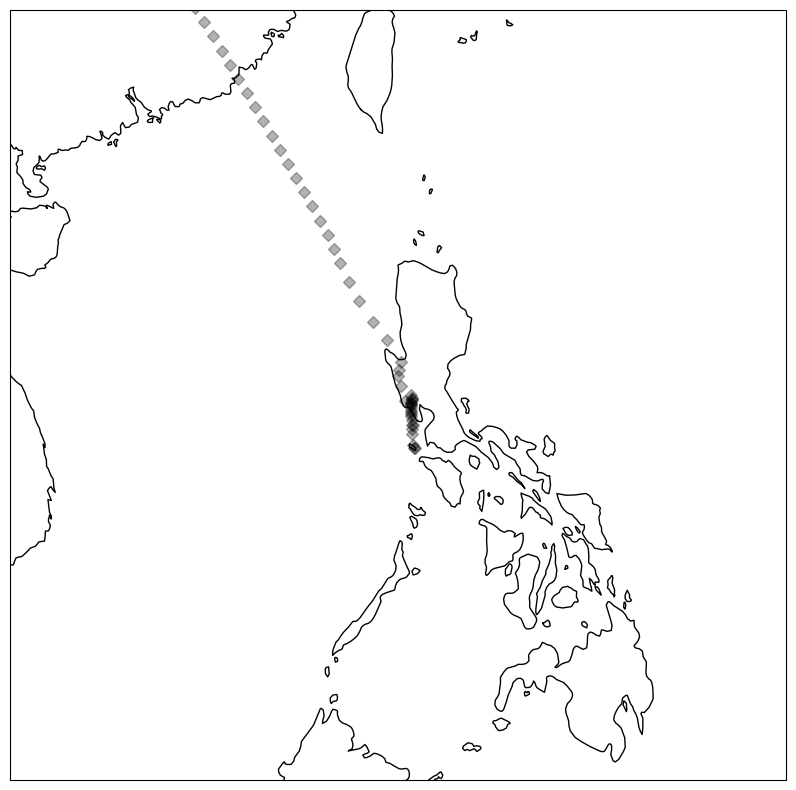

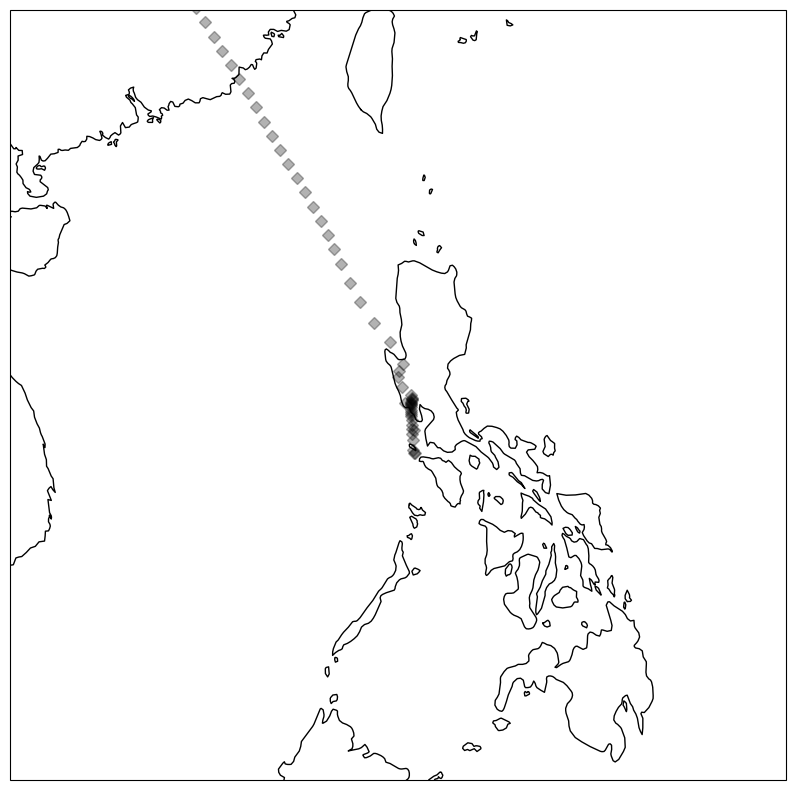

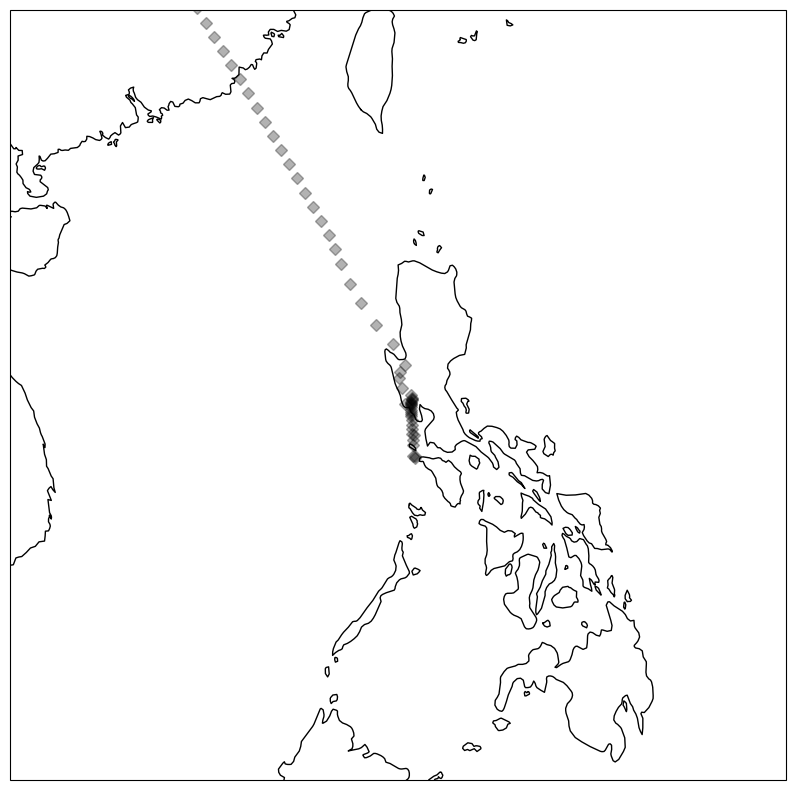

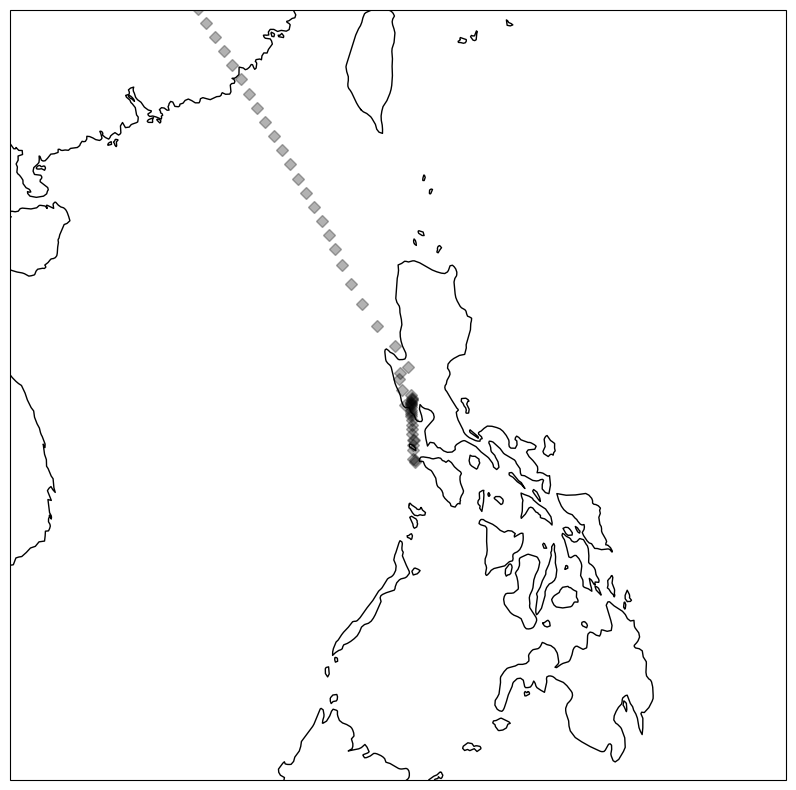

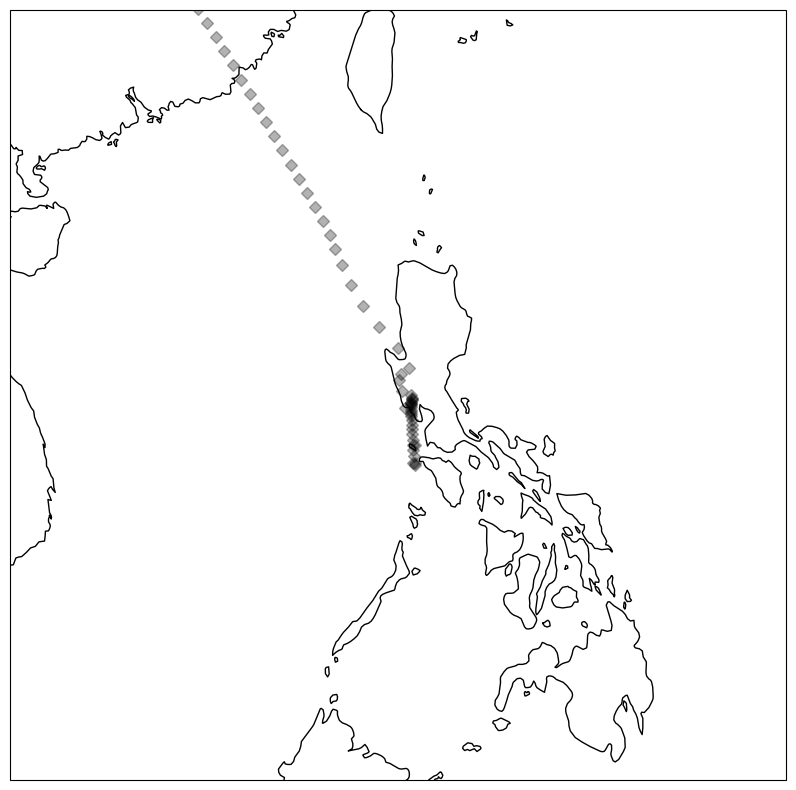

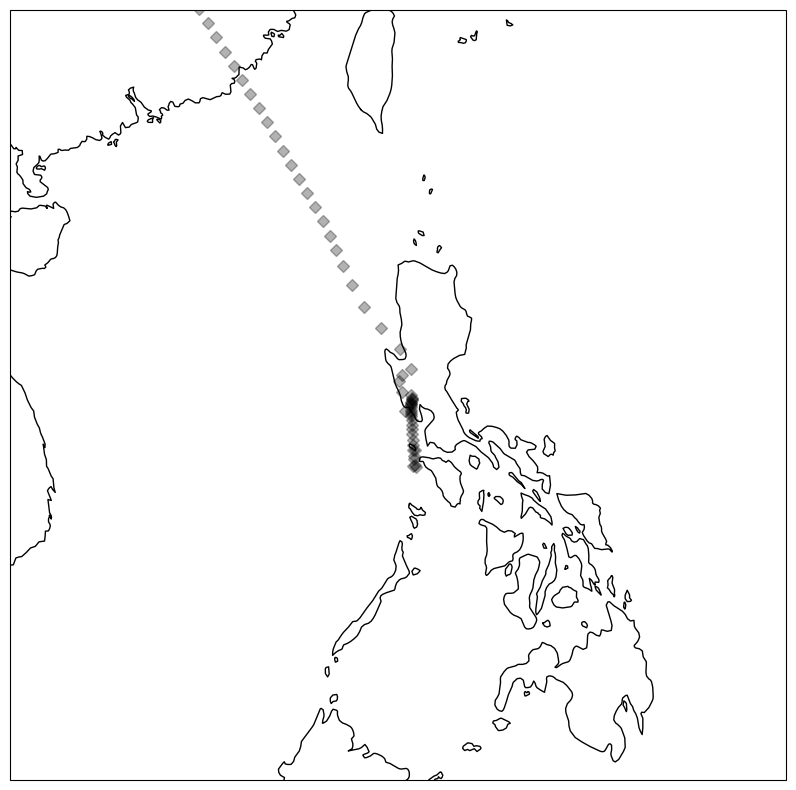

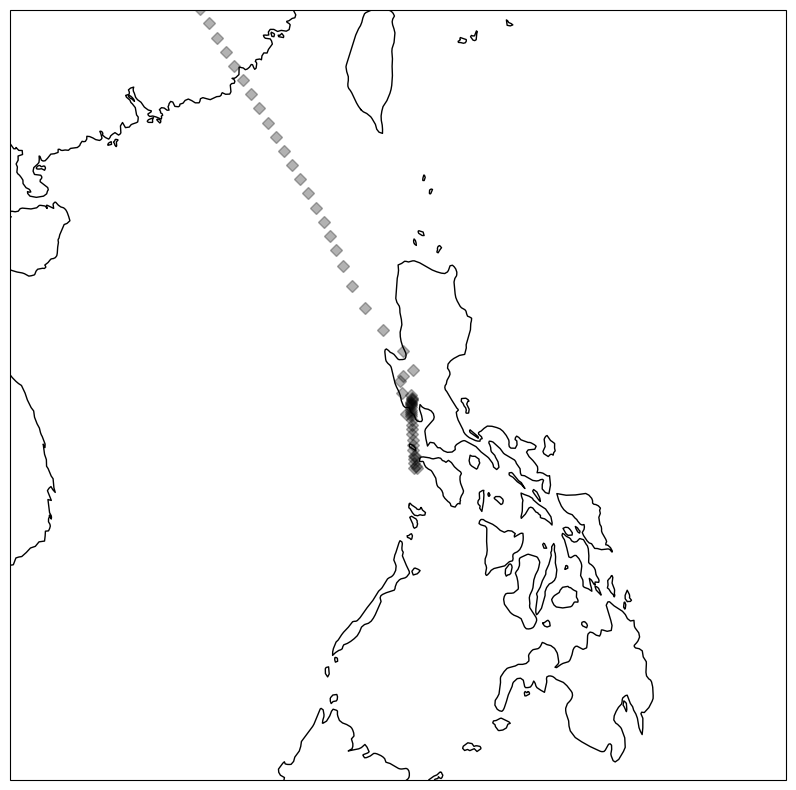

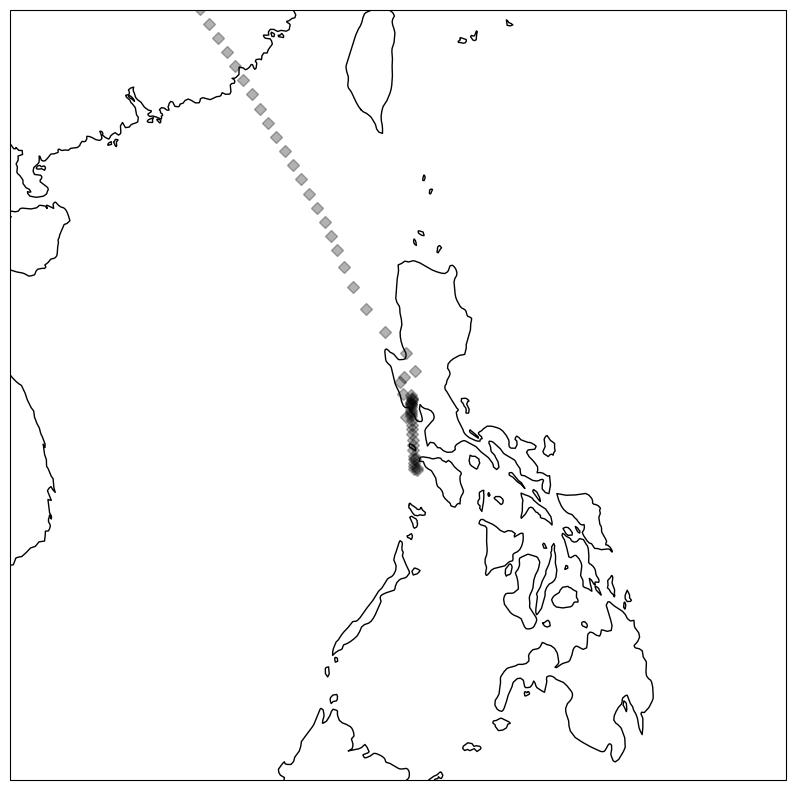

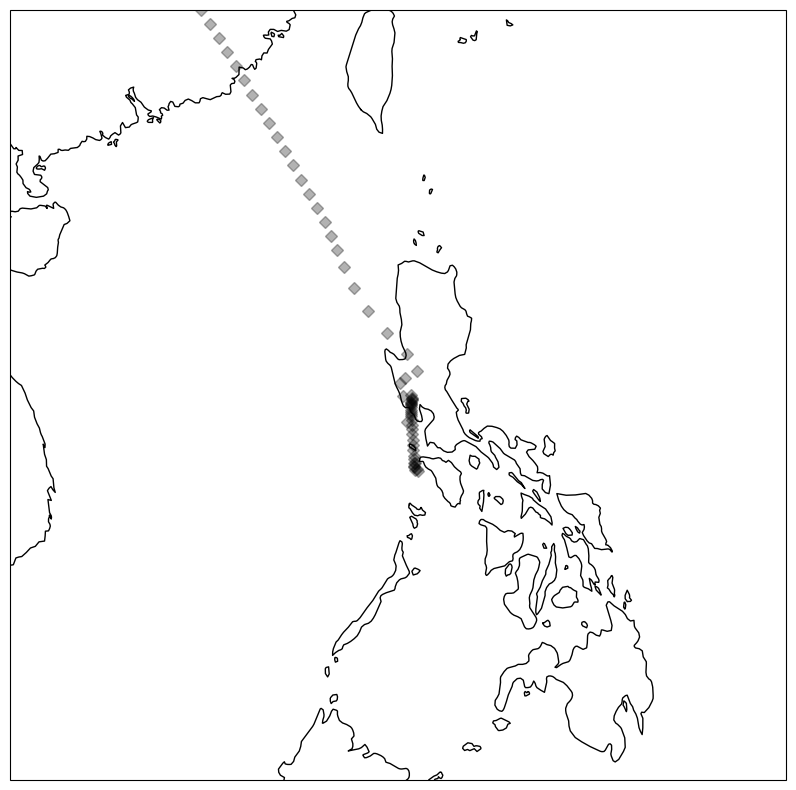

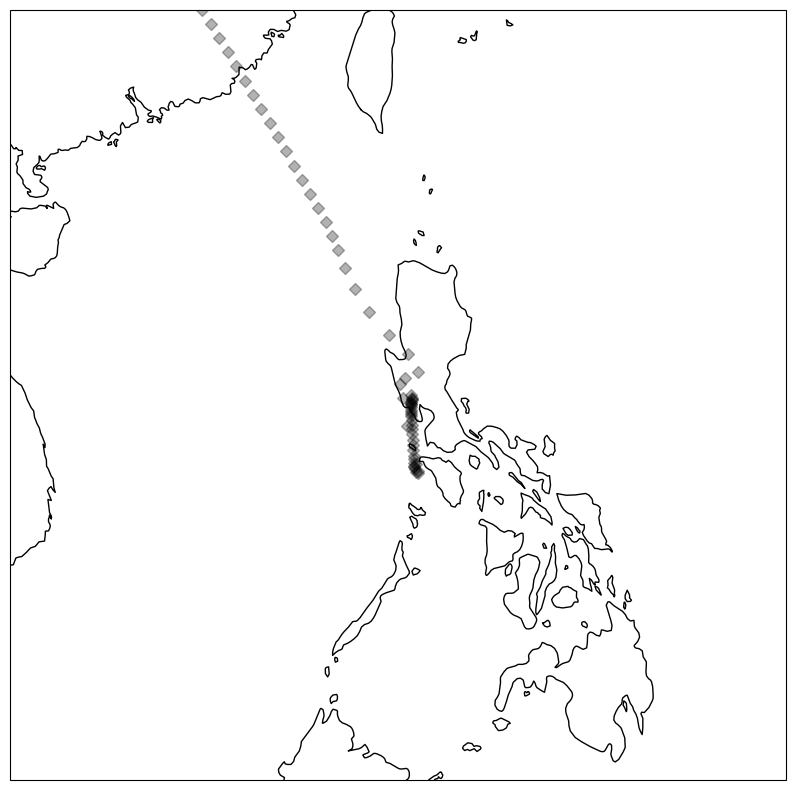

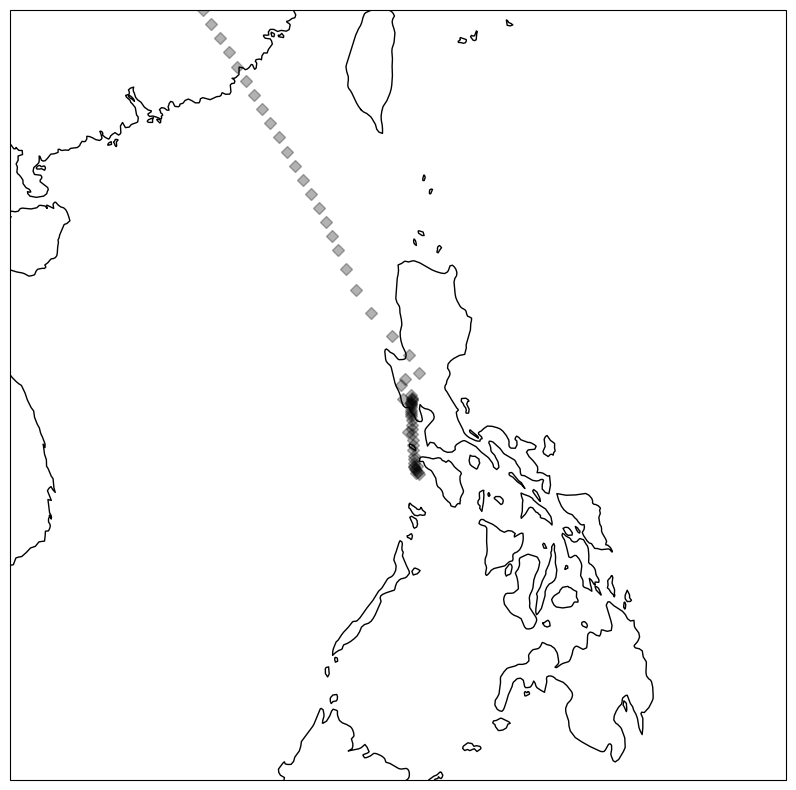

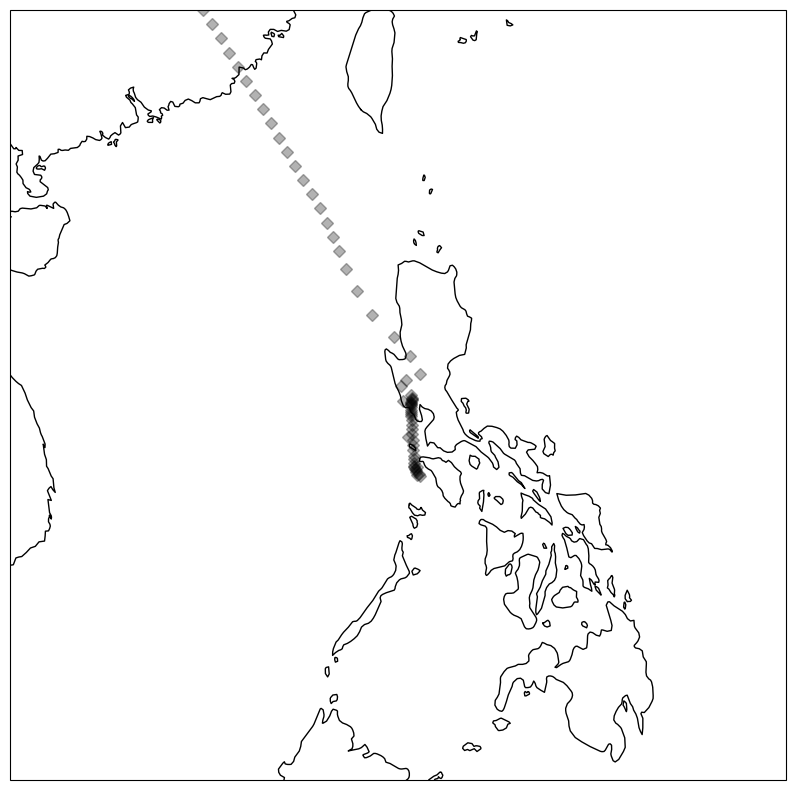

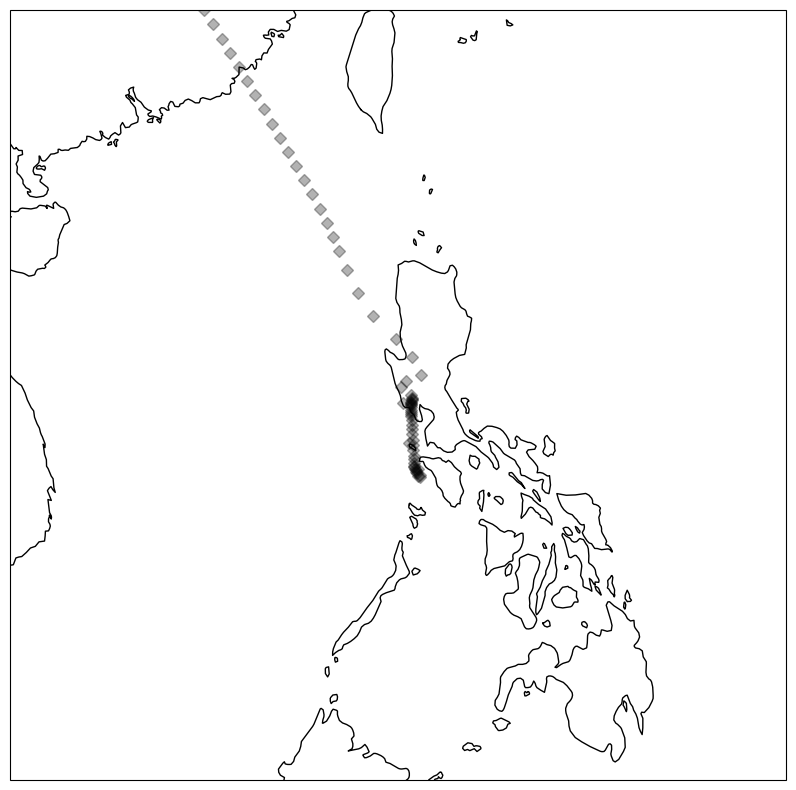

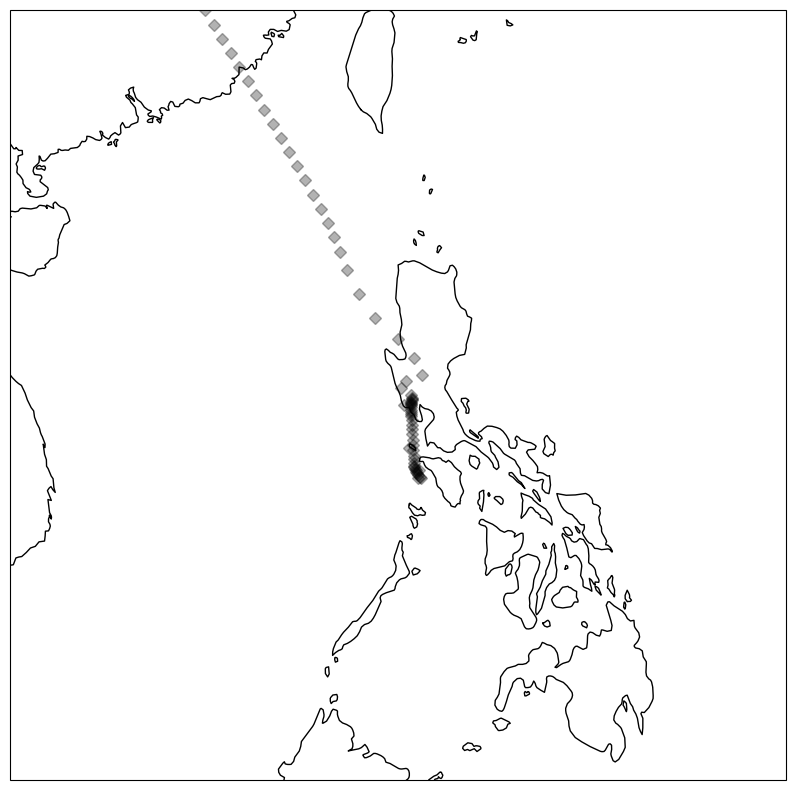

In [25]:
for t in plume_tracers.keys():
    figglobal = plt.figure(figsize=(20,10))
    ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
    # ax.set_global()
    _plot_offset_deg = 10
    axes_extents = (float(active_eruption.lon_deg)-_plot_offset_deg, float(active_eruption.lon_deg)+_plot_offset_deg, float(active_eruption.lat_deg)-_plot_offset_deg, float(active_eruption.lat_deg)+_plot_offset_deg)
    ax.set_extent(axes_extents, crs=ccrs.PlateCarree())
    ax.coastlines()
    for tracer in plume_tracers[t]:
        ax.plot(
            tracer.lon_deg,
            tracer.lat_deg,
            'D',
            transform=ccrs.PlateCarree(),
            color='k',
            alpha=.3,
            )


In [26]:
volcanic_phenomena = volcanic_eruptions
for time, _ptracers in plume_tracers.items():
    volcanic_phenomena.extend(_ptracers)

## Initialize the world, the constellations, and the brokers

In [27]:
# phenomena = []

world_with_brokers = World(satellites = all_satellites, phenomena=volcanic_phenomena)

scheduler_planet = ConstellationGroundScheduler(satellites=dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Planet")
scheduler_umbra = ConstellationGroundScheduler(satellites=umbra_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Umbra")
scheduler_capella = ConstellationGroundScheduler(satellites=capella_acadia_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Capella")
scheduler_LOFT = ConstellationGroundScheduler(satellites=loft_satellites, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=ubotica_satellites, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_mission_control = ConstellationGroundScheduler(satellites=mission_control_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Mission Control")
scheduler_aerospace = ConstellationGroundScheduler(satellites=aerospace_corp_satellites, ground_stations=ground_stations, world=world_with_brokers, name="AC")
scheduler_iceye = ConstellationGroundScheduler(satellites=iceye_satellites, ground_stations=ground_stations, world=world_with_brokers, name="ICEYE")

all_constellations = [scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace, scheduler_iceye]

constcolors = {c.name: constcolorer(c.name) for c in all_constellations}


world_with_brokers.add_constellation(scheduler_planet)
world_with_brokers.add_constellation(scheduler_umbra)
world_with_brokers.add_constellation(scheduler_capella)
world_with_brokers.add_constellation(scheduler_LOFT)
world_with_brokers.add_constellation(scheduler_ubotica)
world_with_brokers.add_constellation(scheduler_mission_control)
world_with_brokers.add_constellation(scheduler_aerospace)
world_with_brokers.add_constellation(scheduler_iceye)

broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers, name="Broker 1")


world_with_brokers.add_broker(broker)

world_with_brokers.time = min_time

We start with some static functions we will use to compute rewards

In [28]:
def rewarder_observation(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 50
    
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    
    zenith_angle_reward = abs(preferred_zenith_angle_deg-opportunity.sun_zenith_angle_deg)/90
    
    # if the Sun is below the horizon
    # if abs(opportunity.sun_zenith_angle_deg)>90 and opportunity.instrument == InstrumentType.RGB:
    #     zenith_angle_reward = -100

    range_reward = 1/(opportunity.range_km/1000)

    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def rewarder_search(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 0
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    zenith_angle_reward = 0
    range_reward = 1/(opportunity.range_km/1000)
    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def success_declarer_eruption(data_product):
    # TODO check that the dp name does not end in plume
    return len(data_product)>0

def success_declarer_plume(data_product):
    # TODO check that the dp name does end in plume
    return len(data_product)>0

In [29]:

def timeline_updater_volcanos(
        current_time: dt.datetime,
        requests: list[ConstrainedObservationRequest],
        timelines: list[Timeline],
        max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800),
        verbose=True
        ):
    # Go through the requests
    # If we saw a given volcano active, mark it as active at a given time
    # Q: how do we know which volcano a request is for? The volcano is
    #  - In the name (with an ugly suffix)
    #  - In the lon lat (but we will move it )
    #  - In the plotting group
    # Then reset the timelines to "the volcano was active at this time in the past"
    # So keep a dict with volcano->last_seen_time
    # If there isn't a reading, then we mark it as inactive now

    volcano_last_seen_active = {t.name: min_time for t in timelines}
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                # TODO check if this is a mass request (OK) or a plume request (ignore)
                volcano_observed = current_request.request_group
                if volcano_observed in volcano_last_seen_active.keys():
                    volcano_last_seen_active[volcano_observed] = max(volcano_last_seen_active[volcano_observed], current_request.observation_opportunity.time)
    
    for timeline in timelines:
        last_seen_time = volcano_last_seen_active[timeline.name]
        tl_measured_value = 0
        if last_seen_time > min_time:
            tl_measured_value = 1
        _current_estimated_value, _current_estimated_rate = timeline._get_value_and_rate_at(last_seen_time, print_debug=False)
        timeline.reset_timeline(last_seen_time, tl_measured_value, _current_estimated_rate)
    
        if verbose:
            print(f"    [Dispatcher] Resetting timeline {timeline.name} to {tl_measured_value} (est rate {_current_estimated_rate}) at time {last_seen_time}")
    return timelines

def propagate_plume(observation_time: dt.datetime, current_time: dt.datetime, plume_location = Pose):
    # Get the wind at the observation time

    wind_uv_ms = get_winds_at_lla_m_s(observation_time, Location(lon_deg = plume_location.lon_deg, lat_deg=plume_location.lat_deg, alt_km=plume_location.alt_km))
    
    propagation_dt = current_time-observation_time

    dy_km = wind_uv_ms[0]*propagation_dt.total_seconds()/1e3 # E-W
    dx_km = wind_uv_ms[1]*propagation_dt.total_seconds()/1e3 # N-S

    dlat_rad = dy_km/R_earth_km
    dlon_rad = dx_km/(R_earth_km*np.cos(plume_location.lat_deg*math.pi/180.))

    new_lat_deg = plume_location.lat_deg + dlat_rad*180./math.pi
    new_lon_deg = plume_location.lon_deg + dlon_rad*180./math.pi
    # Propagate to curent time

    propagated_plume = Location(
        lon_deg=new_lon_deg,
        lat_deg=new_lat_deg,
        alt_km=plume_location.alt_km, # TODO also update altitude...
    )

    return propagated_plume


def request_updater_volcano(
        current_time: dt.datetime,
        requests: list[ConstrainedObservationRequest],
        timelines: list[Timeline]=[],
        verbose=True,
        ):
    # For plume requests:
    # Look at where the plume is now by iterating through requests and building a set of llas
    # Get the wind for these llas
    # Aim somewhere at where they will be

    volcano_names = [t.name for t in timelines]

    plume_locations = {v: [] for v in volcano_names}
    
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                # Check if this is a mass request (ignore) or a plume request (keep)
                is_this_a_plume_request = current_request.request_group.endswith("_plume")
                if is_this_a_plume_request:
                    observed_volcano = current_request.request_group[:-6]
                    if observed_volcano not in plume_locations.keys():
                        raise ValueError("Somethinf wrong with our volcano names")
                    plume_locations[observed_volcano].extend([(current_request.observation_opportunity.time, _dp) for _dp in current_request.data_product])
    # Now we have a bunch of past plume observations
    for observed_volcano in plume_locations.keys():
        plume_locations[observed_volcano].sort(key=lambda x: x[0])
        # We just keep the most recent ones

        recent_plume_locations = plume_locations[observed_volcano][-10:]
        
        # And we propagate the location with wind
        propagated_plume_locations = [
            propagate_plume(observation_time = rpl[0], current_time = current_time, plume_location = rpl[1])

            for rpl in recent_plume_locations
        ]

        if len(propagated_plume_locations):
            # TODO this will do awful things if we roll over the international date line......
            median_plume_location = Location(
                lat_deg = np.median([ppl.lat_deg for ppl in propagated_plume_locations]),
                lon_deg = np.median([ppl.lon_deg for ppl in propagated_plume_locations]),
                alt_km = np.median([ppl.alt_km for ppl in propagated_plume_locations]),
            )

            # And we aim for the center of these observations
            # Find requests for this volcano that are plume-related. These have a request group that ends with _plume and starts with the volcano name
            for request in requests:
                if request.dispatched == False and request.completed == False:
                    if request.request_group == observed_volcano+"_plume":
                        request.observation_request.lon_deg = median_plume_location.lon_deg
                        request.observation_request.lat_deg = median_plume_location.lat_deg
                        request.observation_request.alt_km = median_plume_location.alt_km

    return requests



### Create the workflow proper

In [30]:
# Workflow:
# Mandatory: check each volcano at least once
# If the check succeeds, continue imaging every few hours until the signal fades.
# Implementation: time windows + wait_if_feasible on previous tasks + a timeline for "is the volcano active".


# observations_volcanoes = [
#     ObservationRequest(
#         volcano.lon_deg, volcano.lat_deg, alt_km=volcano.alt_km, 
#         min_time=min_time, max_time=min_time+dt.timedelta(seconds=3600*6),
#         request_name=volcano.name, instrument=InstrumentType.HYPERSPECTRAL
#         )
#     for volcano in volcano_locations
# ]

follow_up_interval_h = 3

constrained_requests_volcanoes = []

are_volcanoes_active_timelines = {
    volcano: Timeline(name=volcano.name, initial_time=min_time, initial_value=1, initial_rate=-1./(3600*24), min_value=-30, max_value=30)
    for volcano in volcano_locations
    }


for volcano in volcano_locations:

    constrained_requests_by_volcano = []

    eruption_detection_request = ConstrainedObservationRequest(
        name = volcano.name,
        observation_request=ObservationRequest(
            lon_deg=volcano.lon_deg, lat_deg=volcano.lat_deg, alt_km=volcano.alt_km, 
            min_time=min_time, max_time=min_time+dt.timedelta(seconds=3600*6),
            request_name=volcano.name, instrument=InstrumentType.HYPERSPECTRAL,
        ),
        is_mandatory=True,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        timeline_constraints=[],
        timeline_impacts=[TaskTimelineImpact(timeline=are_volcanoes_active_timelines[volcano], time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
        rewarder=rewarder_observation,
        success_declarer=success_declarer_eruption,
        request_group=volcano.name,
    )

    eruption_volume_observation = ObservationRequest(
        lon_deg=volcano.lon_deg, lat_deg=volcano.lat_deg, alt_km=volcano.alt_km, 
        min_time=min_time, max_time=max_time,
        request_name=volcano.name, instrument=InstrumentType.RGB
        )

    plume_observation = ObservationRequest(
        lon_deg=volcano.lon_deg, lat_deg=volcano.lat_deg, alt_km=volcano.alt_km, 
        min_time=min_time, max_time=max_time,
        request_name=volcano.name, instrument=InstrumentType.RGB
        )


    constrained_requests_by_volcano.append(eruption_detection_request)

    for follow_up_ix in range(0,lookahead_horizon_h,follow_up_interval_h):
        follow_up_obs_request_volume = ObservationRequest(volcano.lon_deg, volcano.lat_deg, min_time=min_time, max_time=max_time, alt_km=volcano.alt_km, request_name=volcano.name+f"_volume_followup_{follow_up_ix}", instrument=InstrumentType.RGB)
        
        obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, eruption_detection_request, {'offset': dt.timedelta(seconds=3600*follow_up_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, eruption_detection_request, {'offset': dt.timedelta(seconds=3600*(follow_up_ix+follow_up_interval_h))}),
        ]

        for existing_request in constrained_requests_by_volcano:
            obs_task_constraints.append(
                Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
            )

        follow_up_constrained_volume_request = ConstrainedObservationRequest(
            name = follow_up_obs_request_volume.name,
            observation_request=follow_up_obs_request_volume,
            is_mandatory=False,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            task_constraints = obs_task_constraints,
            timeline_constraints=[TaskTimelineConstraint(timeline=are_volcanoes_active_timelines[volcano], time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0.1),],
            timeline_impacts=[],
            rewarder=rewarder_observation,
            success_declarer=success_declarer_eruption,
            request_group=volcano.name,
        )



        follow_up_obs_request_plume = ObservationRequest(volcano.lon_deg, volcano.lat_deg, min_time=min_time, max_time=max_time, alt_km=volcano.alt_km, request_name=volcano.name+f"_plume_followup_{follow_up_ix}", instrument=InstrumentType.RGB)

        follow_up_constrained_plume_request = ConstrainedObservationRequest(
            name = follow_up_obs_request_plume.name,
            observation_request=follow_up_obs_request_plume,
            is_mandatory=False,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            task_constraints = obs_task_constraints,
            timeline_constraints=[TaskTimelineConstraint(timeline=are_volcanoes_active_timelines[volcano], time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0.1),],
            timeline_impacts=[],
            rewarder=rewarder_observation,
            success_declarer=success_declarer_plume,
            request_group=volcano.name+"_plume",
        )

        constrained_requests_by_volcano.append(follow_up_constrained_volume_request)
        constrained_requests_by_volcano.append(follow_up_constrained_plume_request)
    
    constrained_requests_volcanoes.extend(constrained_requests_by_volcano)

workflow_volcanoes = Workflow(
    constrained_observation_requests=constrained_requests_volcanoes,
    timelines=list(are_volcanoes_active_timelines.values()),
    timeline_updater=timeline_updater_volcanos,
    request_updater=request_updater_volcano,
    )

broker.add_workflow(workflow_volcanoes)

# Idea: if there is an eruption, follow up every x hours. 


## Add brokers that are mostly interested in cities

In [31]:
num_cities_to_observe = 25

broker_cities_asia = Broker(
    constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace],
    world=world_with_brokers,
    name="Cities broker (Asia)"
)

broker_cities_america = Broker(
    constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace],
    world=world_with_brokers,
    name="Cities broker (America)"
)

world_with_brokers.add_broker(broker_cities_asia)
world_with_brokers.add_broker(broker_cities_america)

cities_of_the_world = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

cities_of_asia_and_thereabouts_mask = cities_of_the_world.apply(lambda c: (c.lng<-170 or c.lng>26) and (c.lat>-11), axis=1)
cities_of_the_americas_and_thereabouts_mask = cities_of_the_world.apply(lambda c: (c.lng>-170 and c.lng<-30), axis=1)

cities_of_asia_and_thereabouts = cities_of_the_world[cities_of_asia_and_thereabouts_mask]
cities_of_the_americas_and_thereabouts = cities_of_the_world[cities_of_the_americas_and_thereabouts_mask]



sampled_cities_of_asia = cities_of_asia_and_thereabouts.sample(n=num_cities_to_observe,weights='population',axis=0, random_state=0)
sampled_cities_of_americas = cities_of_the_americas_and_thereabouts.sample(n=num_cities_to_observe,weights='population',axis=0, random_state=0)

sampled_observations_asia = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_cities_of_asia.iterrows()
]

sampled_observations_americas = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_cities_of_americas.iterrows()
]

cities_constrained_requests_asia = [
    ConstrainedObservationRequest(
        name = city.name,
        observation_request=city,
        is_mandatory=False,
        timeline_constraints=[],
        timeline_impacts=[],
        rewarder=rewarder_observation,
    ) for city in sampled_observations_asia
]

cities_constrained_requests_americas = [
    ConstrainedObservationRequest(
        name = city.name,
        observation_request=city,
        is_mandatory=False,
        timeline_constraints=[],
        timeline_impacts=[],
        rewarder=rewarder_observation,
    ) for city in sampled_observations_americas
]

cities_workflow_asia = Workflow(
    constrained_observation_requests=cities_constrained_requests_asia,
    timelines=[]    
    )

cities_workflow_america = Workflow(
    constrained_observation_requests=cities_constrained_requests_americas,
    timelines=[]    
    )

broker_cities_asia.add_workflow(cities_workflow_asia)
broker_cities_america.add_workflow(cities_workflow_america)



#### Set up plotting

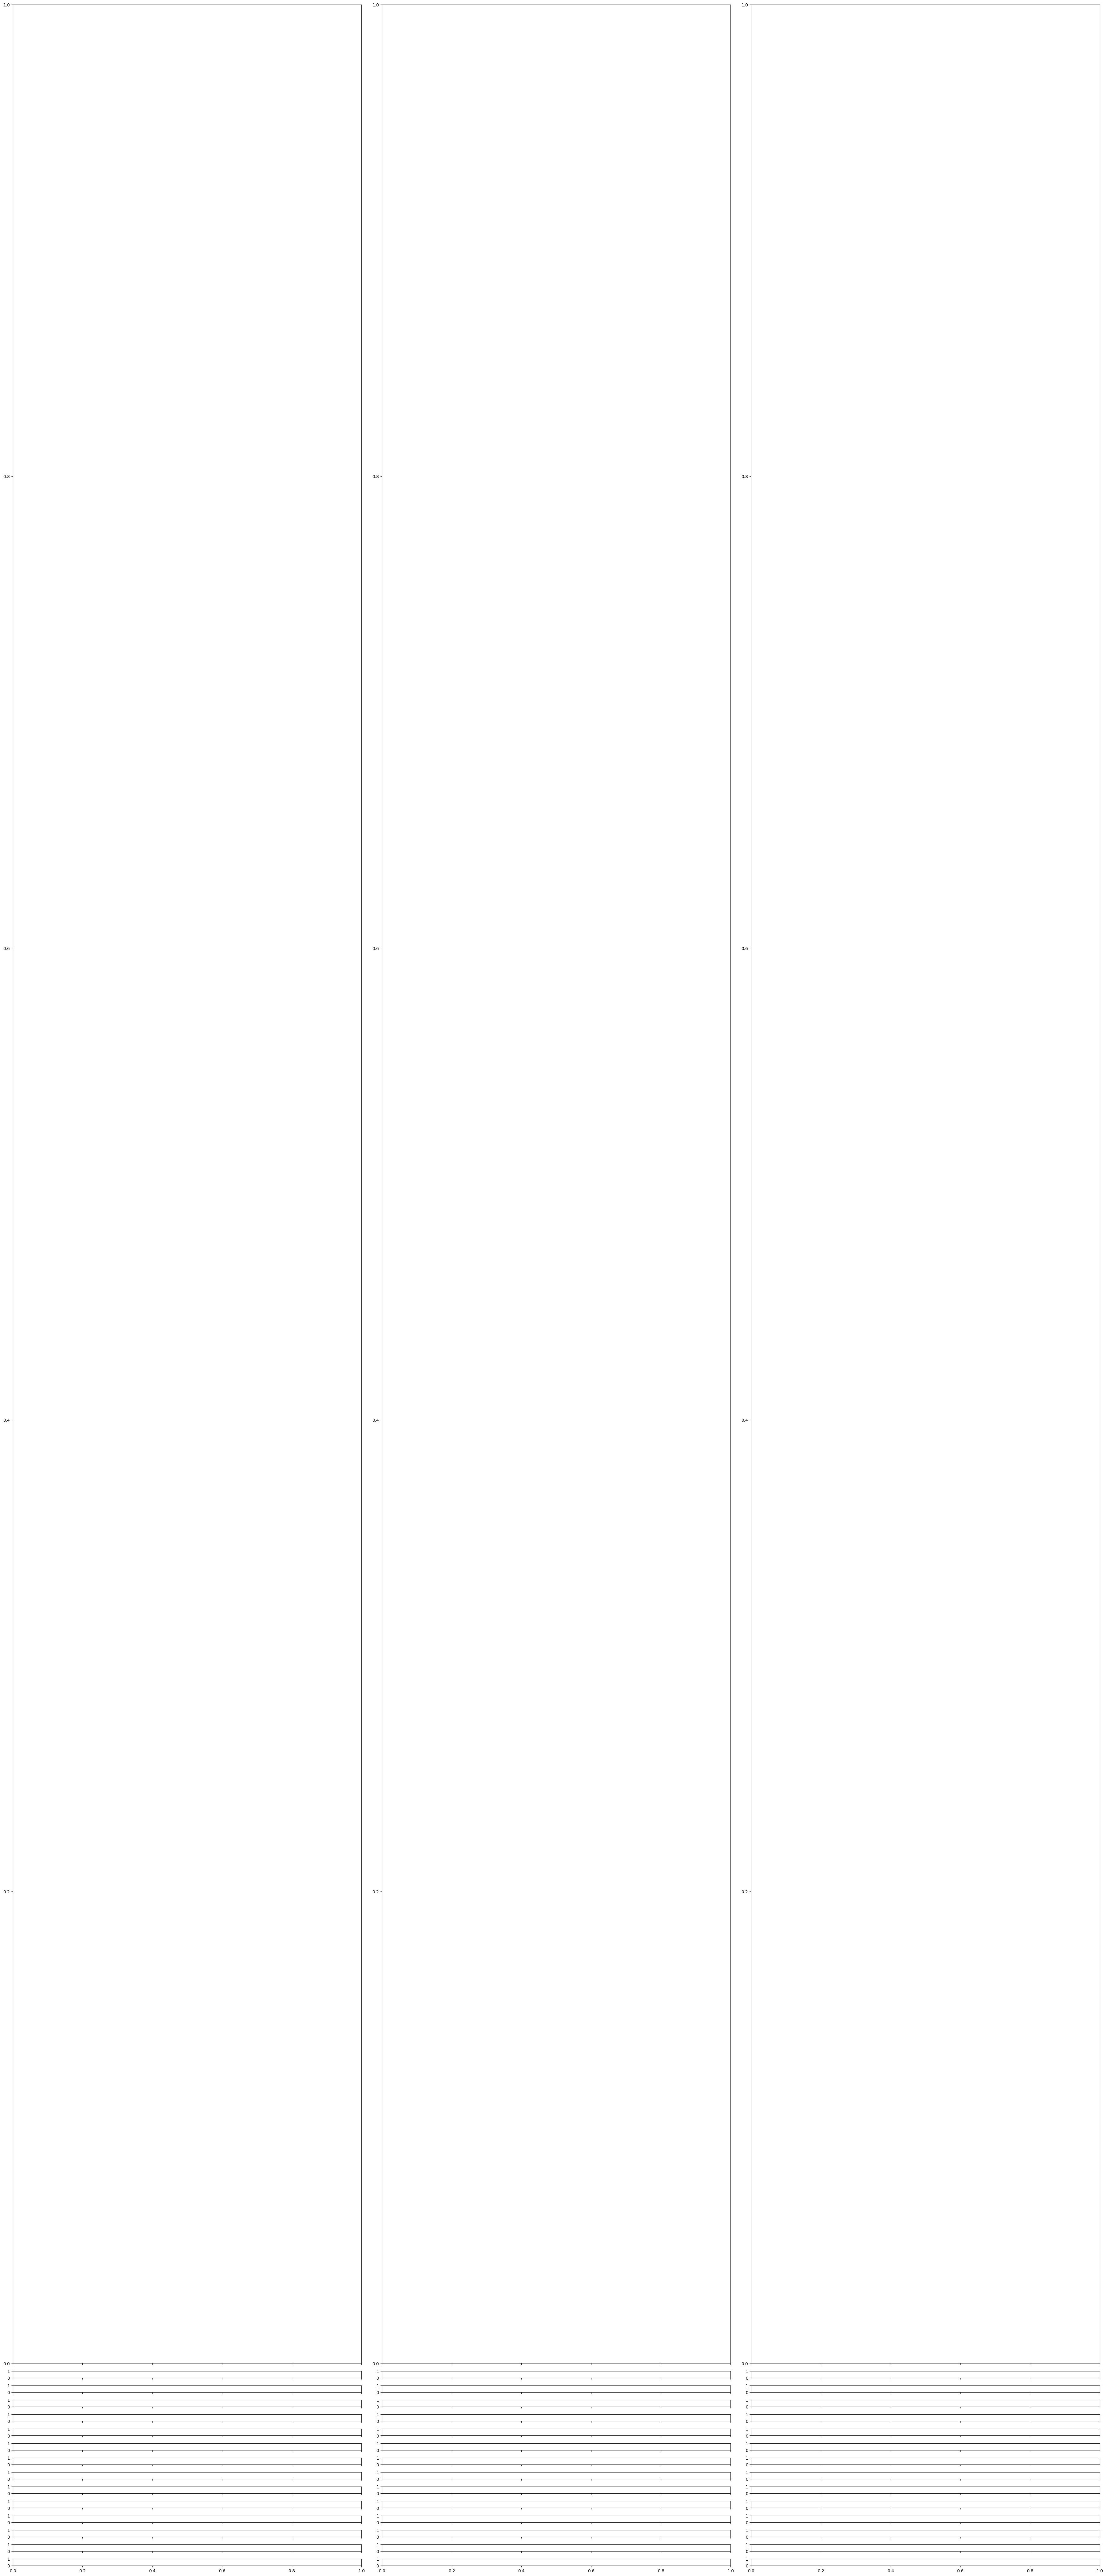

In [32]:
# Plot the timelines

num_requests = max([len(b.workflow.constrained_observation_requests) for b in world_with_brokers.brokers if b.workflow is not None])
num_timelines = max([len(b.workflow.timelines) for b in world_with_brokers.brokers if b.workflow is not None])

height_ratios = [num_requests]
height_ratios.extend([1,]*num_timelines)

fig, baxes = plt.subplots(
    num_timelines+1,
    len(world_with_brokers.brokers),
    sharex=True,
    height_ratios=height_ratios,
    figsize=(12*len(world_with_brokers.brokers), int(math.ceil(.2*num_requests+num_timelines))),
    layout="constrained"
    )

broker_axes = {}
if len(world_with_brokers.brokers)>1:
    for broker_ix, _broker in enumerate(world_with_brokers.brokers):
        if num_timelines>0:
            broker_axes[_broker] = baxes[:, broker_ix]
        else:
            broker_axes[_broker] = baxes[broker_ix]
else:
    broker_axes[world_with_brokers.brokers[0]] = baxes

## Start the workflows!

Function ILP scheduler, the solver engine is GUROBI
   [Scheduler] WG: MultiDiGraph with 350 nodes and 4704 edges
CPLEX not found, trying SCIP
    [Scheduler] Exporting to MPS and solving with Native Gurobi...
    [Scheduler] Waiting for OS I/O to finish writing file...
    [Scheduler] MPS file flush confirmed!
    [Scheduler]  Hunga Tonga-Hunga Ha'apai_Ubotica ACCENTURE-1 SUAC_Pass start: 2026-06-17 21:22:09.079909, highest: 2026-06-17 21:27:41.625989, fall: 2026-06-17 21:33:15.097850  =  1.0
    [Scheduler]  Hunga Tonga-Hunga Ha'apai_volume_followup_0_PELICAN-3001_Pass start: 2026-06-17 23:30:11.482718, highest: 2026-06-17 23:34:51.529790, fall: 2026-06-17 23:39:35.633101  =  1.0
    [Scheduler]  Hunga Tonga-Hunga Ha'apai_plume_followup_0_PELICAN-300A_Pass start: 2026-06-17 22:09:43.971319, highest: 2026-06-17 22:14:58.914818, fall: 2026-06-17 22:20:28.761206  =  1.0
    [Scheduler]  Hunga Tonga-Hunga Ha'apai_volume_followup_3_SKYSAT-C11_Pass start: 2026-06-18 02:48:53.619099, highes

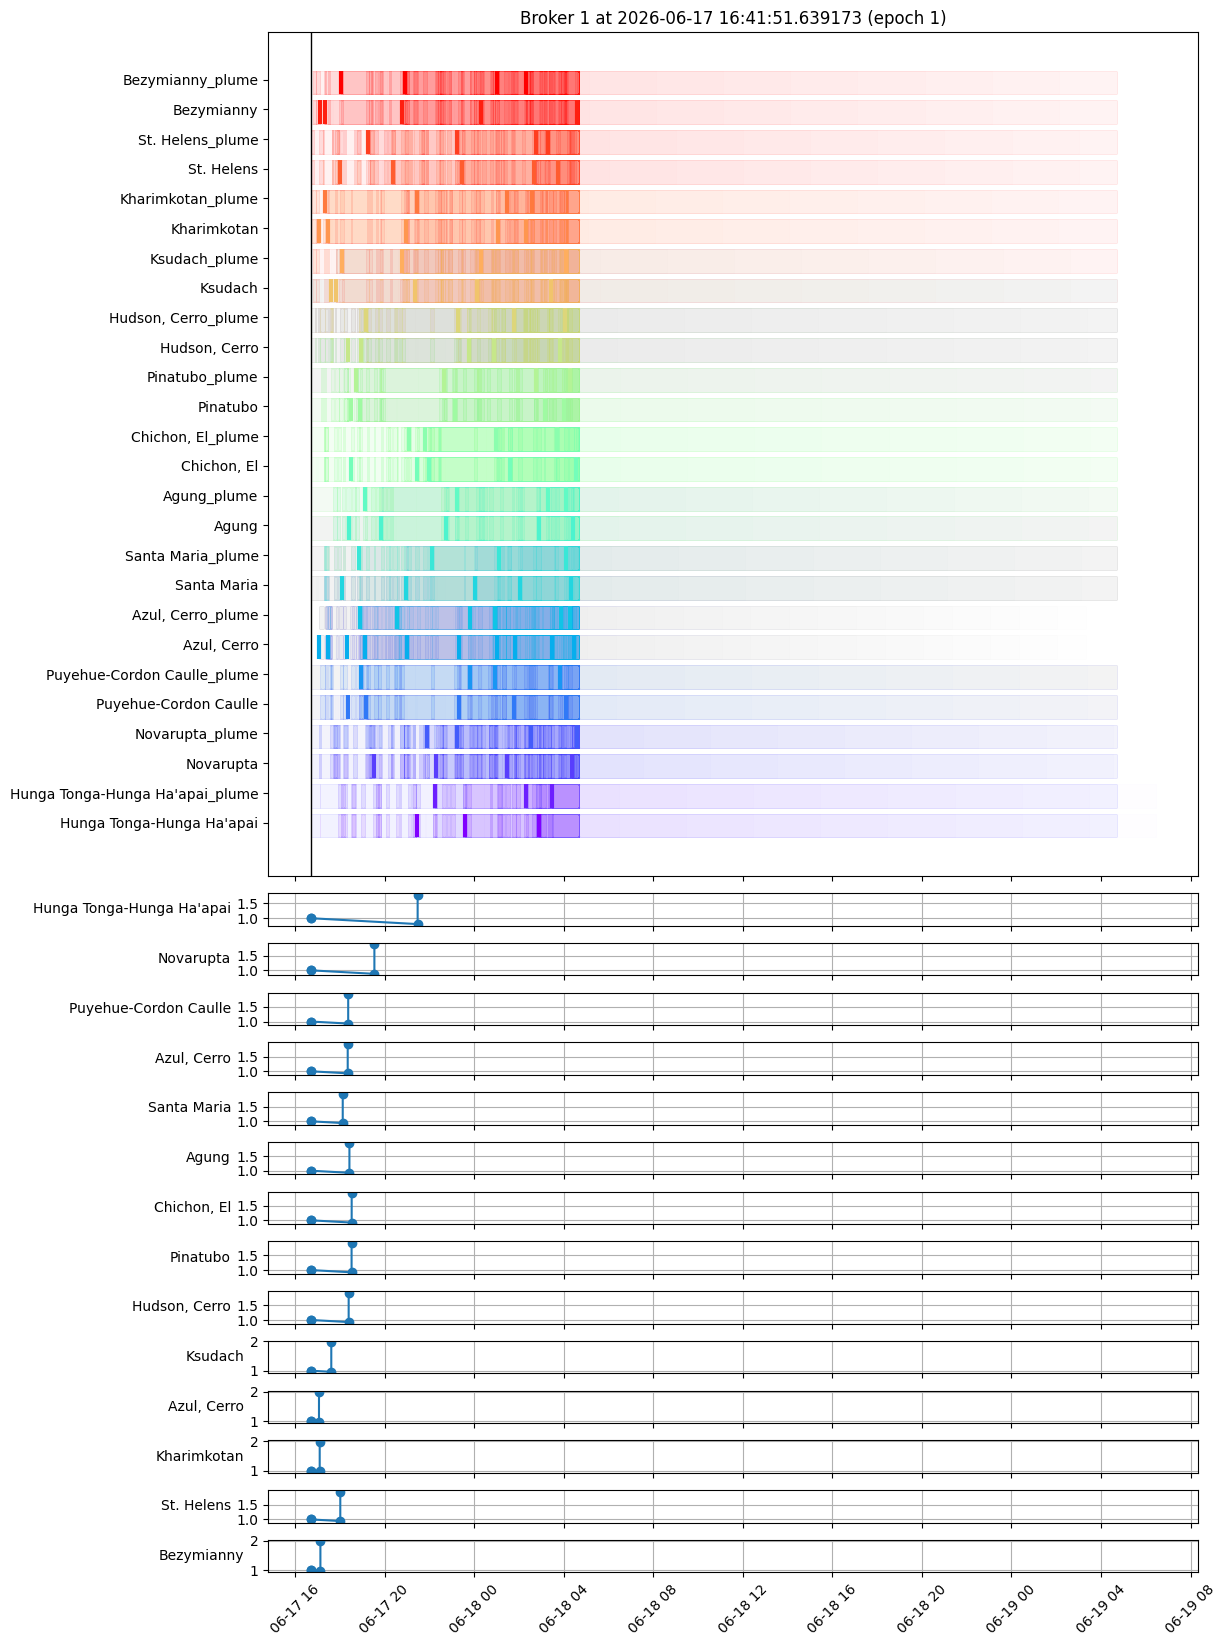

In [33]:
broker.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=True,
    plot_schedule=True,
    # plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=False,
    # plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=True,
    max_solver_time_s=300,
    solver_engine="GUROBI"
)

In [34]:
broker_cities_asia.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=True,
    plot_schedule=False,
    # plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=True,
    # plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=True,
    max_solver_time_s=300
)

Function ILP scheduler, the solver engine is GUROBI
   [Scheduler] WG: MultiDiGraph with 25 nodes and 0 edges
CPLEX not found, trying SCIP
    [Scheduler] Exporting to MPS and solving with Native Gurobi...
    [Scheduler] Waiting for OS I/O to finish writing file...
    [Scheduler] MPS file flush confirmed!
    [Scheduler]  Huzhou_SKYSAT-C9_Pass start: 2026-06-17 18:14:38.583167, highest: 2026-06-17 18:19:54.927264, fall: 2026-06-17 18:25:20.320945  =  1.0
    [Scheduler]  Morogoro_PELICAN-300B_Pass start: 2026-06-17 20:06:53.619426, highest: 2026-06-17 20:12:11.346204, fall: 2026-06-17 20:17:37.031883  =  1.0
    [Scheduler]  Rānchi_PELICAN-3001_Pass start: 2026-06-17 18:10:16.112386, highest: 2026-06-17 18:14:53.532659, fall: 2026-06-17 18:19:39.022327  =  1.0
    [Scheduler]  Jiangyin_SKYSAT-C10_Pass start: 2026-06-17 18:01:18.175062, highest: 2026-06-17 18:06:46.607651, fall: 2026-06-17 18:12:11.098484  =  1.0
    [Scheduler]  Tongren_SKYSAT-C11_Pass start: 2026-06-17 19:54:30.9227

In [ ]:
broker_cities_america.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=True,
    plot_schedule=False,
    # plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=True,
    # plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=True,
    max_solver_time_s=300
)

Function ILP scheduler, the solver engine is GUROBI
   [Scheduler] WG: MultiDiGraph with 25 nodes and 0 edges
CPLEX not found, trying SCIP
    [Scheduler] Exporting to MPS and solving with Native Gurobi...
    [Scheduler] Waiting for OS I/O to finish writing file...
    [Scheduler] MPS file flush confirmed!
    [Scheduler]  Longueuil_PELICAN-3009_Pass start: 2026-06-18 03:42:11.604586, highest: 2026-06-18 03:47:37.530455, fall: 2026-06-18 03:52:54.606656  =  1.0
    [Scheduler]  Farmington Hills_PELICAN-300A_Pass start: 2026-06-18 03:42:53.339561, highest: 2026-06-18 03:48:07.386383, fall: 2026-06-18 03:53:38.283672  =  1.0
    [Scheduler]  Juazeiro_PELICAN-3001_Pass start: 2026-06-18 03:11:21.233810, highest: 2026-06-18 03:15:56.410524, fall: 2026-06-18 03:20:33.136932  =  1.0
    [Scheduler]  Peoria_PELICAN-3001_Pass start: 2026-06-17 18:39:27.365481, highest: 2026-06-17 18:44:03.391289, fall: 2026-06-17 18:48:51.526033  =  1.0
    [Scheduler]  Maturín_PELICAN-3009_Pass start: 2026-0

: 

In [ ]:
retcode = 1
while (retcode !=0):
    retcode = world_with_brokers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])

Executing Event Obs, sat TANAGER-4001 at 2026-06-17 17:03:16.635192
Executing Event ISL Downlink from sat TANAGER-4001 at 2026-06-17 17:03:16.635192
Spacecraft TANAGER-4001 has 1 data products to download
  Downlinked Observation  at 2026-06-17 17:03:16.635192 by TANAGER-4001 with InstrumentType.HYPERSPECTRAL. Look angle 101.30739567418627 | 10.70896247348138 az/dec deg, zenith angle 28.781905218591998 deg, range 1487.7912708864628 km, duration 0:01:00
 [Broker 1: ] data ready for request Request Azul, Cerro, pass Pass start: 2026-06-17 16:59:02.509788, highest: 2026-06-17 17:03:16.844727, fall: 2026-06-17 17:07:31.998029, from Planet
    [Dispatcher] Resetting timeline Hunga Tonga-Hunga Ha'apai to 0 (est rate -1.1574074074074073e-05) at time 2026-06-17 16:41:51.639173
    [Dispatcher] Resetting timeline Novarupta to 0 (est rate -1.1574074074074073e-05) at time 2026-06-17 16:41:51.639173
    [Dispatcher] Resetting timeline Puyehue-Cordon Caulle to 0 (est rate -1.1574074074074073e-05) a

c:\Users\davidf\federated-scheduling\fame_workflow.py:1368: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(num_timelines+1,1, sharex=True, height_ratios=height_ratios, figsize=(12, int(math.ceil(.2*num_request_groups+num_timelines))))


 [Broker 1] There are 0 dispatchable tasks
Executing Event Obs, sat PELICAN-300B at 2026-06-18 04:05:20.478423
Executing Event ISL Downlink from sat PELICAN-300B at 2026-06-18 04:05:20.478423
Spacecraft PELICAN-300B has 1 data products to download
  Downlinked Observation  at 2026-06-18 04:05:20.478423 by PELICAN-300B with InstrumentType.RGB. Look angle 89.79799886321906 | 61.73345162347207 az/dec deg, zenith angle 135.3407930411303 deg, range 501.3692831086427 km, duration 0:01:00
 [Cities broker (America): ] data ready for request Request Jalapa, pass Pass start: 2026-06-18 04:00:06.935644, highest: 2026-06-18 04:05:30.910458, fall: 2026-06-18 04:10:45.952182, from Planet
Function ILP scheduler, the solver engine is GUROBI
   [Scheduler] WG: MultiDiGraph with 25 nodes and 0 edges
CPLEX not found, trying SCIP
   [Scheduler] Request Longueuil is already dispatched or completed, skipping
   [Scheduler] Request Farmington Hills is already dispatched or completed, skipping
   [Scheduler] 

In [ ]:
save_prefix = "media/volcanos_v6"

In [ ]:
# with open(f"{save_prefix}_chronicle.pkl",'wb') as file:
#     dill.dump(world_with_brokers.history, file)

In [ ]:
retell_history(world_with_brokers)

In [ ]:
fig, stats_axes = plt.subplots(2,2)

stats_axes_linear = [stats_axes[0][0], stats_axes[1][0], stats_axes[0][1], stats_axes[1][1]]

plot_request_statistics(broker._requests, axes=stats_axes_linear, constellation_colors=constcolors)

# request_statistics(broker._requests)

In [ ]:
figglobal = plt.figure(figsize=(10,5))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

_plot_offset_deg = 10

# mapcenter = Location(lon_deg=3.8, lat_deg=60, alt_km=0)

# axes_extents = (float(mapcenter.lon_deg)-_plot_offset_deg, float(mapcenter.lon_deg)+_plot_offset_deg, float(mapcenter.lat_deg)-_plot_offset_deg, float(mapcenter.lat_deg)+_plot_offset_deg)
# ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

for _chronicle in world_with_brokers.history:
    if type(_chronicle['event']) in [ObservationEvent]:
        _ax = plot_event(
            _chronicle,
            world_with_brokers,
            ax=ax,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolors,
            plot_time=False,
            plot_phenomena=False,
            plot_satellite_tracks=False,
            plot_ground_stations=False,
            plot_observation_gaze=True,
            plot_observation_target=True,
            plot_satellites=True
            )
        
# ax.plot([pos.lon_deg for pos in phenomena_rotterdam],[pos.lat_deg for pos in phenomena_rotterdam],transform=ccrs.Geodetic(), label="TOI trajectory (Rotterdam)")
# ax.plot([pos.lon_deg for pos in phenomena_gothenburg],[pos.lat_deg for pos in phenomena_gothenburg],transform=ccrs.Geodetic(), label="TOI trajectory (Gothenburg)")
# plt.savefig("media/MSA2_observations_2ships_v2_sigmahdg_{}_sigmav_{}.png".format(heading_variance, speed_variance),bbox_inches='tight')
# plt.savefig("media/MSA2_observations_2ships_v2_sigmahdg_{}_sigmav_{}.pdf".format(heading_variance, speed_variance),bbox_inches='tight')


In [ ]:
phenomena_colors = {'Pinatubo': [1, 0, 0], 'Plume Pinatubo': [.5, .5, .5, .1]}

In [ ]:
figglobal = plt.figure(figsize=(10,5))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

# mapcenter = Location(lon_deg=3.8, lat_deg=60, alt_km=0)

# axes_extents = (float(mapcenter.lon_deg)-_plot_offset_deg, float(mapcenter.lon_deg)+_plot_offset_deg, float(mapcenter.lat_deg)-_plot_offset_deg, float(mapcenter.lat_deg)+_plot_offset_deg)
# ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

_plot_offset_deg = 10
axes_extents = (float(active_eruption.lon_deg)-_plot_offset_deg, float(active_eruption.lon_deg)+_plot_offset_deg, float(active_eruption.lat_deg)-_plot_offset_deg, float(active_eruption.lat_deg)+_plot_offset_deg)
ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

for _chronicle in world_with_brokers.history:
    if type(_chronicle['event']) in [ObservationEvent]:
        _ax = plot_event(
            _chronicle,
            world_with_brokers,
            ax=ax,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolors,
            plot_time=False,
            plot_phenomena=True,
            plot_satellite_tracks=False,
            plot_ground_stations=False,
            plot_observation_gaze=True,
            plot_observation_target=False,
            plot_satellites=True,
            plot_observation_footprint=True,
            phenomena_colors=phenomena_colors,
            )
        
# ax.plot([pos.lon_deg for pos in phenomena_rotterdam],[pos.lat_deg for pos in phenomena_rotterdam],transform=ccrs.Geodetic(), label="TOI trajectory (Rotterdam)")
# ax.plot([pos.lon_deg for pos in phenomena_gothenburg],[pos.lat_deg for pos in phenomena_gothenburg],transform=ccrs.Geodetic(), label="TOI trajectory (Gothenburg)")
plt.savefig("media/volcanos_v6.png",bbox_inches='tight')
plt.savefig("media/volcanos_v6.pdf",bbox_inches='tight')


In [ ]:
print("There were {} observations".format(len([_e for _e in world_with_brokers.history if (type(_e['event']) in [ObservationEvent,])])))

In [ ]:
def plot_chronicle_volcano(
        chronicle: dict,
        world: World,
        satellite_colors: dict={},
        satellite_markers: dict={},
        constellation_colors: dict={},
        local_axes_extent: tuple=None,
        plot_time: bool=True,
        plot_phenomena: bool=True,
        phenomena_colors: dict= {},
        plot_ground_stations: bool=True,
        plot_satellites: bool=True,
        plot_satellite_tracks: bool=True,
        plot_observation_gaze: bool=True,
        plot_observation_target: bool=True,
        plot_observation_footprint: bool=True,
        plot_comm_gaze: bool=True,
        plot_comm_station: bool=True,
        show_night: bool=False,
        show_night_location: Location= Location(-118,34, 0),
        time_limits: list=[None, None],
        position_filter_parameters: dict={},
        ):

    num_brokers = len(chronicle['states']['brokers'])
    top_mosaic_row = ["Event_global"]
    if local_axes_extent:
        top_mosaic_row = ["Event_local"]
    # mid_mosaic_row = ["Event_global"]
    # mid_mosaic_row.extend([f"Broker {i} timeline" for i in range(num_brokers)])
    bottom_mosaic_row = ["Event_global"]
    for i in range(num_brokers):
        top_mosaic_row.extend([f"Broker {i} events", f"Broker {i} events"])
        # mid_mosaic_row.extend([f"Broker {i} timeline", f"Broker {i} timeline"])
        bottom_mosaic_row.extend([f"Broker {i} stats A", f"Broker {i} stats B" ])

    mosaic_rows = [top_mosaic_row, bottom_mosaic_row]

    width_ratios = [5]

    width_ratios.extend([1.3, 0.7]*num_brokers)
    height_ratios = [2,1]

    per_subplot_kw={
        "Event_global": {"projection": ccrs.Robinson()},
    }
    if local_axes_extent:
        per_subplot_kw["Event_local"] = {"projection": ccrs.Robinson()}

    fig, axes = plt.subplot_mosaic(
        mosaic_rows,
        per_subplot_kw=per_subplot_kw,
        height_ratios=height_ratios,
        width_ratios=width_ratios,
        figsize=[14+6*num_brokers,10]
        )
    
    # Plot the event: satellites overhead, observations
    axes['Event_global'].set_global()
    axes['Event_global'].coastlines()

    if local_axes_extent:
        axes['Event_local'].set_extent(local_axes_extent, crs=ccrs.PlateCarree())
        axes['Event_local'].coastlines()

    plot_time_global = plot_time
    plot_phenomena_global = plot_phenomena


    # Turn off some things for redundancy
    if local_axes_extent:
        plot_time_global = False
        plot_phenomena_global = False
    
    plot_event(
        _chronicle=chronicle,
        world=world,
        ax=axes['Event_global'],
        satellite_colors=satellite_colors,
        satellite_markers=satellite_markers,
        constellation_colors=constellation_colors,
        plot_time=plot_time_global,
        plot_phenomena=plot_phenomena_global,
        plot_satellite_tracks=plot_satellite_tracks,
        plot_ground_stations=plot_ground_stations,
        plot_observation_gaze=plot_observation_gaze,
        plot_observation_target=plot_observation_target,
        plot_satellites=plot_satellites,
        plot_observation_footprint=plot_observation_footprint,
        plot_comm_gaze=plot_comm_gaze,
        plot_comm_station=plot_comm_station,
        phenomena_colors=phenomena_colors,
        )
    
    if local_axes_extent:
        plot_event(
            _chronicle=chronicle,
            world=world,
            ax=axes['Event_local'],
            satellite_colors=satellite_colors,
            satellite_markers=satellite_markers,
            constellation_colors=constellation_colors,
            plot_time=plot_time,
            plot_phenomena=plot_phenomena,
            plot_satellite_tracks=plot_satellite_tracks,
            plot_ground_stations=plot_ground_stations,
            plot_observation_gaze=plot_observation_gaze,
            plot_observation_target=plot_observation_target,
            plot_satellites=plot_satellites,
            plot_observation_footprint=plot_observation_footprint,
            plot_comm_gaze=plot_comm_gaze,
            plot_comm_station=plot_comm_station,
            phenomena_colors=phenomena_colors,
            )
    
    # For each broker, plot the schedule, at the current time
    for broker_ix, broker in enumerate(chronicle['states']['brokers']):

        plot_workflow_schedule(
            workflow_graph=broker._workflow_graph,
            timeline_graph=broker._timeline_graph,
            # axes=[axes[f"Broker {broker_ix} events"], axes[f"Broker {broker_ix} timeline"]],
            axes=axes[f"Broker {broker_ix} events"],
            time=chronicle['time'],
            feasibility_screener=broker._screen_pass_for_feasibility,
            plot_title=f"{broker.name} (epoch {broker._workflow_schedule_epoch})",
            show_night=show_night,
            show_night_location=show_night_location,
            save_schedule_plot=False,
            # save_name = "Schedule_e{}_{}.pdf".format(self._workflow_schedule_epoch, self.world.time)
            )
        if (len(time_limits)>=2 and (time_limits[0] is not None) and (time_limits[1] is not None)):
            axes[f"Broker {broker_ix} events"].set_xlim(time_limits[0],time_limits[1])
        # Plot the statistics, histograms
        # dump_fig, dump_axes = plt.subplots(3,1)
        stats_axes = [None, None, axes[f"Broker {broker_ix} stats A"], axes[f"Broker {broker_ix} stats B"]]
        if (len(time_limits)>=2 and (time_limits[0] is not None) and (time_limits[1] is not None)):
            axes[f"Broker {broker_ix} stats A"].set_xlim(time_limits[0],time_limits[1])
        plot_request_statistics(
            broker._requests,
            axes=stats_axes,
            constellation_colors=constellation_colors,
            save_plots=False,
            show_titles=False,
            show_percentages=False,
            )

    # Plot the tracker distributions

    # fig.autofmt_xdate()

In [ ]:
PLOT_HISTORY_CHRONICLE = True
times = [c['time'] for c in world_with_brokers.history]

_plot_offset_deg = 8
local_axes_extent = (float(active_eruption.lon_deg)-_plot_offset_deg, float(active_eruption.lon_deg)+_plot_offset_deg, float(active_eruption.lat_deg)-_plot_offset_deg, float(active_eruption.lat_deg)+_plot_offset_deg)

if PLOT_HISTORY_CHRONICLE:
    for chronicle_ix, chronicle in enumerate(world_with_brokers.history):
        plot_chronicle_volcano(
            chronicle=chronicle,
            world=world_with_brokers,
            local_axes_extent=local_axes_extent,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolors,
            show_night=False,
            plot_time=True,
            plot_phenomena=True,
            phenomena_colors=phenomena_colors,
            plot_satellite_tracks=True,
            plot_ground_stations=False,
            plot_observation_gaze=True,
            plot_observation_target=False,
            plot_satellites=False,
            time_limits = [min(times), max(times)],
            )

        plt.savefig("{}{:05d}.png".format(save_prefix+"_chronicles_", chronicle_ix), bbox_inches='tight')
        plt.close()
